In [1]:
# =========================================================
# PORTION 1 : IMPORTS + CONFIG + DATASET
# =========================================================

import os
import gc
import cv2
import random
import warnings

import numpy as np
import pandas as pd

from pathlib import Path
from PIL import Image

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

from torchvision import transforms

from sklearn.model_selection import train_test_split

from sklearn.metrics import (

    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (

    CLIPModel,
    AutoTokenizer,
    AutoModel
)

warnings.filterwarnings("ignore")

# =========================================================
# GPU CONFIG
# =========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("DEVICE:", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

# =========================================================
# PATHS
# =========================================================

DATASET_PATH = "/kaggle/input/datasets/ajfaisal002/crossmodal-misleading-video-dataset"

TRAIN_FRAMES = os.path.join(
    DATASET_PATH,
    "dataset_kaggle/extracted_frames/train"
)

TEST_FRAMES = os.path.join(
    DATASET_PATH,
    "dataset_kaggle/extracted_frames/test"
)

TRAIN_META = os.path.join(
    DATASET_PATH,
    "dataset_kaggle/extracted_text/train_metadata.csv"
)

TEST_META = os.path.join(
    DATASET_PATH,
    "dataset_kaggle/extracted_text/test_metadata.csv"
)

# =========================================================
# LOAD CSV
# =========================================================

train_df = pd.read_csv(TRAIN_META)

test_df = pd.read_csv(TEST_META)

print("\nTrain shape:", train_df.shape)
print("Test shape :", test_df.shape)

# =========================================================
# CLEAN TEXT
# =========================================================

for df in [train_df, test_df]:

    df["transcript"] = df["transcript"].fillna("")

    df["ocr_text"] = df["ocr_text"].fillna("")

# =========================================================
# STAGE-1 LABELS
# safe = 0
# misleading = 1
# =========================================================

train_df["label_stage1"] = train_df[
    "category"
].apply(
    lambda x: 0 if x == "safe" else 1
)

test_df["label_stage1"] = test_df[
    "category"
].apply(
    lambda x: 0 if x == "safe" else 1
)

# =========================================================
# STAGE-2 LABELS
# =========================================================

stage2_map = {

    "identity_fabrication": 0,
    "perception_manipulation": 1,
    "scientifically_unrealistic_scene": 2,
    "surreal_content": 3
}

train_df["label_stage2"] = train_df[
    "subcategory"
].map(stage2_map)

test_df["label_stage2"] = test_df[
    "subcategory"
].map(stage2_map)

# =========================================================
# TRAIN / VALIDATION SPLIT
# =========================================================

train_df, val_df = train_test_split(

    train_df,

    test_size=0.15,

    stratify=train_df["label_stage1"],

    random_state=SEED
)

train_df = train_df.reset_index(drop=True)

val_df = val_df.reset_index(drop=True)

# =========================================================
# DISTRIBUTION
# =========================================================

print("\nTRAIN:", len(train_df))
print("VAL  :", len(val_df))
print("TEST :", len(test_df))

print("\nStage1 Distribution:")
print(
    train_df["label_stage1"]
    .value_counts()
)

print("\nStage2 Distribution:")
print(
    train_df["subcategory"]
    .value_counts()
)

# =========================================================
# IMAGE TRANSFORM
# =========================================================

frame_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.48145466, 0.4578275, 0.40821073],

        std=[0.26862954, 0.26130258, 0.27577711]
    )
])

print("\nPORTION 1 COMPLETE ✅")

DEVICE: cuda
GPU: Tesla T4

Train shape: (1600, 6)
Test shape : (800, 6)

TRAIN: 1360
VAL  : 240
TEST : 800

Stage1 Distribution:
label_stage1
1    680
0    680
Name: count, dtype: int64

Stage2 Distribution:
subcategory
scientifically_unrealistic_scene    172
perception_manipulation             171
identity_fabrication                170
surreal_content                     167
Name: count, dtype: int64

PORTION 1 COMPLETE ✅


In [2]:
# =========================================================
# PORTION 2 : DATASET + DATALOADER
# =========================================================

# =========================================================
# LOAD TOKENIZER
# =========================================================

tokenizer = AutoTokenizer.from_pretrained(
    "xlm-roberta-base"
)

print("Tokenizer loaded ✅")

# =========================================================
# LOAD 16 FRAMES
# =========================================================

def load_frames(video_id, split="train"):

    if split == "train":

        root = TRAIN_FRAMES

    else:

        root = TEST_FRAMES

    video_dir = os.path.join(
        root,
        video_id
    )

    frames = []

    for i in range(1,17):

        frame_path = os.path.join(
            video_dir,
            f"frame_{i:02d}.jpg"
        )

        # -----------------------------
        # EXISTING FRAME
        # -----------------------------

        if os.path.exists(frame_path):

            img = Image.open(
                frame_path
            ).convert("RGB")

            img = frame_transform(img)

        # -----------------------------
        # MISSING FRAME
        # -----------------------------

        else:

            img = torch.zeros(
                3,
                224,
                224
            )

        frames.append(img)

    frames = torch.stack(frames)

    return frames

# =========================================================
# BUILD TEXT
# =========================================================

def build_text(transcript, ocr):

    transcript = str(transcript).strip()

    ocr = str(ocr).strip()

    text = transcript + " " + ocr

    text = text.strip()

    if len(text) == 0:

        text = "[NO_TEXT]"

    return text

# =========================================================
# DATASET
# =========================================================

class MultimodalDataset(Dataset):

    def __init__(self, df, split="train"):

        self.df = df

        self.split = split

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        video_id = row["video_id"]

        # =================================================
        # FRAMES
        # =================================================

        frames = load_frames(
            video_id,
            self.split
        )

        # =================================================
        # TEXT
        # =================================================

        text = build_text(

            row["transcript"],

            row["ocr_text"]
        )

        # =================================================
        # LABELS
        # =================================================

        label_stage1 = int(
            row["label_stage1"]
        )

        # stage2 may be NaN for SAFE

        if pd.isna(row["label_stage2"]):

            label_stage2 = -1

        else:

            label_stage2 = int(
                row["label_stage2"]
            )

        return {

            "video_id": video_id,

            "frames": frames,

            "text": text,

            "label_stage1": torch.tensor(
                label_stage1,
                dtype=torch.long
            ),

            "label_stage2": torch.tensor(
                label_stage2,
                dtype=torch.long
            )
        }

# =========================================================
# COLLATE FUNCTION
# =========================================================

def collate_fn(batch):

    video_ids = [
        x["video_id"]
        for x in batch
    ]

    frames = torch.stack([
        x["frames"]
        for x in batch
    ])

    texts = [
        x["text"]
        for x in batch
    ]

    # =====================================================
    # TOKENIZE
    # =====================================================

    tokens = tokenizer(

        texts,

        padding=True,

        truncation=True,

        max_length=128,

        return_tensors="pt"
    )

    label_stage1 = torch.stack([

        x["label_stage1"]
        for x in batch

    ])

    label_stage2 = torch.stack([

        x["label_stage2"]
        for x in batch

    ])

    return {

        "video_ids": video_ids,

        "frames": frames,

        "input_ids": tokens["input_ids"],

        "attention_mask": tokens[
            "attention_mask"
        ],

        "texts": texts,

        "label_stage1": label_stage1,

        "label_stage2": label_stage2
    }

# =========================================================
# CREATE DATASETS
# =========================================================

train_dataset = MultimodalDataset(

    train_df,
    split="train"
)

val_dataset = MultimodalDataset(

    val_df,
    split="train"
)

test_dataset = MultimodalDataset(

    test_df,
    split="test"
)

print("Datasets created ✅")

# =========================================================
# DATALOADERS
# =========================================================

BATCH_SIZE = 8

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=True,

    collate_fn=collate_fn
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True,

    collate_fn=collate_fn
)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True,

    collate_fn=collate_fn
)

print("Dataloaders created ✅")

# =========================================================
# QUICK TEST
# =========================================================

batch = next(iter(train_loader))

print("\nFRAMES:")
print(batch["frames"].shape)

print("\nINPUT IDS:")
print(batch["input_ids"].shape)

print("\nATTENTION MASK:")
print(batch["attention_mask"].shape)

print("\nSTAGE1 LABELS:")
print(batch["label_stage1"].shape)

print("\nSTAGE2 LABELS:")
print(batch["label_stage2"].shape)

print("\nPORTION 2 COMPLETE ✅")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded ✅
Datasets created ✅
Dataloaders created ✅

FRAMES:
torch.Size([8, 16, 3, 224, 224])

INPUT IDS:
torch.Size([8, 128])

ATTENTION MASK:
torch.Size([8, 128])

STAGE1 LABELS:
torch.Size([8])

STAGE2 LABELS:
torch.Size([8])

PORTION 2 COMPLETE ✅


In [3]:
# =========================================================
# PORTION 3 : FEATURE EXTRACTORS + TEMPORAL ATTENTION
# =========================================================

print("Loading CLIP...")

clip_model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(DEVICE)

clip_model.eval()

# =========================================================
# FREEZE CLIP
# =========================================================

for p in clip_model.parameters():

    p.requires_grad = False

print("CLIP loaded + frozen ✅")

# =========================================================
# LOAD XLM-R
# =========================================================

print("\nLoading XLM-R...")

text_model = AutoModel.from_pretrained(
    "xlm-roberta-base"
).to(DEVICE)

text_model.eval()

# =========================================================
# FREEZE XLM-R
# =========================================================

for p in text_model.parameters():

    p.requires_grad = False

print("XLM-R loaded + frozen ✅")

# =========================================================
# SAFE CLIP EMBEDDING
# =========================================================

def clip_embed(pixel_values):

    outputs = clip_model.vision_model(
        pixel_values=pixel_values
    )

    # --------------------------------------------
    # SAFE VERSION
    # fixes HF output mismatch
    # --------------------------------------------

    if hasattr(outputs, "pooler_output"):

        feats = outputs.pooler_output

    else:

        feats = outputs.last_hidden_state.mean(
            dim=1
        )

    return feats

# =========================================================
# TEMPORAL ATTENTION
# =========================================================

class TemporalAttention(nn.Module):

    def __init__(self, dim=768):

        super().__init__()

        self.attn = nn.Sequential(

            nn.Linear(dim, 256),

            nn.ReLU(),

            nn.Linear(256, 1)
        )

    def forward(self, x):

        # x = (B,T,768)

        weights = torch.softmax(

            self.attn(x),

            dim=1
        )

        out = (x * weights).sum(dim=1)

        return out, weights

# =========================================================
# STAGE-1 MODEL
# =========================================================

class Stage1Model(nn.Module):

    def __init__(self):

        super().__init__()

        self.temporal_attn = TemporalAttention(
            768
        )

        self.classifier = nn.Sequential(

            nn.Linear(768 + 768, 512),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(512, 2)
        )

    # =====================================================
    # ENCODE FRAMES
    # =====================================================

    def encode_frames(self, frames):

        B, T, C, H, W = frames.shape

        frames = frames.view(
            B*T,
            C,
            H,
            W
        ).to(DEVICE)

        with torch.no_grad():

            feats = clip_embed(frames)

        # --------------------------------------------
        # reshape back
        # --------------------------------------------

        feats = feats.view(B, T, -1)

        # temporal attention

        video_feat, weights = self.temporal_attn(
            feats
        )

        return video_feat, weights

    # =====================================================
    # ENCODE TEXT
    # =====================================================

    def encode_text(
        self,
        input_ids,
        attention_mask
    ):

        input_ids = input_ids.to(DEVICE)

        attention_mask = attention_mask.to(
            DEVICE
        )

        with torch.no_grad():

            outputs = text_model(

                input_ids=input_ids,

                attention_mask=attention_mask
            )

        text_feat = outputs.last_hidden_state[
            :,
            0,
            :
        ]

        return text_feat

    # =====================================================
    # FORWARD
    # =====================================================

    def forward(

        self,

        frames,

        input_ids,

        attention_mask
    ):

        video_feat, weights = self.encode_frames(
            frames
        )

        text_feat = self.encode_text(

            input_ids,

            attention_mask
        )

        fusion = torch.cat([

            video_feat,

            text_feat

        ], dim=1)

        logits = self.classifier(fusion)

        return logits, weights

# =========================================================
# STAGE-2 MODEL
# =========================================================

class Stage2Model(nn.Module):

    def __init__(self):

        super().__init__()

        self.temporal_attn = TemporalAttention(
            768
        )

        self.classifier = nn.Sequential(

            nn.Linear(768 + 768, 512),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(512, 4)
        )

    def encode_frames(self, frames):

        B, T, C, H, W = frames.shape

        frames = frames.view(
            B*T,
            C,
            H,
            W
        ).to(DEVICE)

        with torch.no_grad():

            feats = clip_embed(frames)

        feats = feats.view(B, T, -1)

        video_feat, weights = self.temporal_attn(
            feats
        )

        return video_feat, weights

    def encode_text(

        self,

        input_ids,

        attention_mask
    ):

        input_ids = input_ids.to(DEVICE)

        attention_mask = attention_mask.to(
            DEVICE
        )

        with torch.no_grad():

            outputs = text_model(

                input_ids=input_ids,

                attention_mask=attention_mask
            )

        text_feat = outputs.last_hidden_state[
            :,
            0,
            :
        ]

        return text_feat

    def forward(

        self,

        frames,

        input_ids,

        attention_mask
    ):

        video_feat, weights = self.encode_frames(
            frames
        )

        text_feat = self.encode_text(

            input_ids,

            attention_mask
        )

        fusion = torch.cat([

            video_feat,

            text_feat

        ], dim=1)

        logits = self.classifier(fusion)

        return logits, weights

# =========================================================
# CREATE MODELS
# =========================================================

stage1_model = Stage1Model().to(DEVICE)

stage2_model = Stage2Model().to(DEVICE)

print("\nStage1 model created ✅")

print("Stage2 model created ✅")

# =========================================================
# PARAM COUNTS
# =========================================================

def count_params(model):

    return sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad
    )

print("\nStage1 trainable params:")
print(count_params(stage1_model))

print("\nStage2 trainable params:")
print(count_params(stage2_model))

# =========================================================
# QUICK GPU TEST
# =========================================================

batch = next(iter(train_loader))

frames = batch["frames"]

input_ids = batch["input_ids"]

attention_mask = batch[
    "attention_mask"
]

with torch.no_grad():

    out1, w1 = stage1_model(

        frames,

        input_ids,

        attention_mask
    )

    out2, w2 = stage2_model(

        frames,

        input_ids,

        attention_mask
    )

print("\nStage1 output:")
print(out1.shape)

print("\nStage1 attention:")
print(w1.shape)

print("\nStage2 output:")
print(out2.shape)

print("\nStage2 attention:")
print(w2.shape)

print("\nPORTION 3 COMPLETE ✅")

Loading CLIP...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

CLIP loaded + frozen ✅

Loading XLM-R...


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


XLM-R loaded + frozen ✅

Stage1 model created ✅
Stage2 model created ✅

Stage1 trainable params:
985091

Stage2 trainable params:
986117

Stage1 output:
torch.Size([8, 2])

Stage1 attention:
torch.Size([8, 16, 1])

Stage2 output:
torch.Size([8, 4])

Stage2 attention:
torch.Size([8, 16, 1])

PORTION 3 COMPLETE ✅


In [4]:
# =========================================================
# PORTION 4 : TRAINING + VALIDATION FUNCTIONS
# =========================================================

from tqdm import tqdm

import torch.optim as optim

from torch.cuda.amp import (
    autocast,
    GradScaler
)

# =========================================================
# LOSS FUNCTIONS
# =========================================================

criterion_stage1 = nn.CrossEntropyLoss()

criterion_stage2 = nn.CrossEntropyLoss()

# =========================================================
# OPTIMIZERS
# =========================================================

optimizer_stage1 = optim.Adam(

    stage1_model.parameters(),

    lr=1e-4
)

optimizer_stage2 = optim.Adam(

    stage2_model.parameters(),

    lr=1e-4
)

# =========================================================
# MIXED PRECISION
# =========================================================

scaler1 = GradScaler()

scaler2 = GradScaler()

print("Optimizers + Scalers ready ✅")

# =========================================================
# TRAIN STAGE-1
# =========================================================

def train_stage1_epoch():

    stage1_model.train()

    total_loss = 0

    preds_all = []

    labels_all = []

    loop = tqdm(train_loader)

    for batch in loop:

        frames = batch["frames"].to(DEVICE)

        input_ids = batch["input_ids"].to(
            DEVICE
        )

        attention_mask = batch[
            "attention_mask"
        ].to(DEVICE)

        labels = batch[
            "label_stage1"
        ].to(DEVICE)

        optimizer_stage1.zero_grad()

        # -------------------------------------------------
        # AMP
        # -------------------------------------------------

        with autocast():

            logits, _ = stage1_model(

                frames,

                input_ids,

                attention_mask
            )

            loss = criterion_stage1(
                logits,
                labels
            )

        scaler1.scale(loss).backward()

        scaler1.step(optimizer_stage1)

        scaler1.update()

        total_loss += loss.item()

        preds = torch.argmax(
            logits,
            dim=1
        )

        preds_all.extend(
            preds.detach().cpu().numpy()
        )

        labels_all.extend(
            labels.detach().cpu().numpy()
        )

        loop.set_description(

            f"Loss: {loss.item():.4f}"
        )

    acc = accuracy_score(

        labels_all,
        preds_all
    )

    f1 = f1_score(

        labels_all,
        preds_all,
        average="macro"
    )

    return total_loss / len(train_loader), acc, f1

# =========================================================
# VALIDATE STAGE-1
# =========================================================

@torch.no_grad()

def validate_stage1():

    stage1_model.eval()

    preds_all = []

    labels_all = []

    total_loss = 0

    for batch in val_loader:

        frames = batch["frames"].to(DEVICE)

        input_ids = batch["input_ids"].to(
            DEVICE
        )

        attention_mask = batch[
            "attention_mask"
        ].to(DEVICE)

        labels = batch[
            "label_stage1"
        ].to(DEVICE)

        logits, _ = stage1_model(

            frames,

            input_ids,

            attention_mask
        )

        loss = criterion_stage1(
            logits,
            labels
        )

        total_loss += loss.item()

        preds = torch.argmax(
            logits,
            dim=1
        )

        preds_all.extend(
            preds.cpu().numpy()
        )

        labels_all.extend(
            labels.cpu().numpy()
        )

    acc = accuracy_score(

        labels_all,
        preds_all
    )

    f1 = f1_score(

        labels_all,
        preds_all,
        average="macro"
    )

    return (

        total_loss / len(val_loader),

        acc,

        f1,

        labels_all,

        preds_all
    )

# =========================================================
# TRAIN STAGE-2
# ONLY MISLEADING SAMPLES
# =========================================================

def train_stage2_epoch():

    stage2_model.train()

    total_loss = 0

    preds_all = []

    labels_all = []

    loop = tqdm(train_loader)

    for batch in loop:

        # -------------------------------------------------
        # ONLY MISLEADING
        # -------------------------------------------------

        mask = batch["label_stage1"] == 1

        if mask.sum() == 0:

            continue

        frames = batch["frames"][
            mask
        ].to(DEVICE)

        input_ids = batch["input_ids"][
            mask
        ].to(DEVICE)

        attention_mask = batch[
            "attention_mask"
        ][mask].to(DEVICE)

        labels = batch[
            "label_stage2"
        ][mask].to(DEVICE)

        optimizer_stage2.zero_grad()

        with autocast():

            logits, _ = stage2_model(

                frames,

                input_ids,

                attention_mask
            )

            loss = criterion_stage2(
                logits,
                labels
            )

        scaler2.scale(loss).backward()

        scaler2.step(optimizer_stage2)

        scaler2.update()

        total_loss += loss.item()

        preds = torch.argmax(
            logits,
            dim=1
        )

        preds_all.extend(
            preds.detach().cpu().numpy()
        )

        labels_all.extend(
            labels.detach().cpu().numpy()
        )

        loop.set_description(

            f"Loss: {loss.item():.4f}"
        )

    acc = accuracy_score(
        labels_all,
        preds_all
    )

    f1 = f1_score(
        labels_all,
        preds_all,
        average="macro"
    )

    return total_loss / len(train_loader), acc, f1

# =========================================================
# VALIDATE STAGE-2
# =========================================================

@torch.no_grad()

def validate_stage2():

    stage2_model.eval()

    preds_all = []

    labels_all = []

    total_loss = 0

    for batch in val_loader:

        mask = batch["label_stage1"] == 1

        if mask.sum() == 0:

            continue

        frames = batch["frames"][
            mask
        ].to(DEVICE)

        input_ids = batch["input_ids"][
            mask
        ].to(DEVICE)

        attention_mask = batch[
            "attention_mask"
        ][mask].to(DEVICE)

        labels = batch[
            "label_stage2"
        ][mask].to(DEVICE)

        logits, _ = stage2_model(

            frames,

            input_ids,

            attention_mask
        )

        loss = criterion_stage2(
            logits,
            labels
        )

        total_loss += loss.item()

        preds = torch.argmax(
            logits,
            dim=1
        )

        preds_all.extend(
            preds.cpu().numpy()
        )

        labels_all.extend(
            labels.cpu().numpy()
        )

    acc = accuracy_score(

        labels_all,
        preds_all
    )

    f1 = f1_score(

        labels_all,
        preds_all,
        average="macro"
    )

    return (

        total_loss / len(val_loader),

        acc,

        f1,

        labels_all,

        preds_all
    )

print("\nPORTION 4 COMPLETE ✅")

Optimizers + Scalers ready ✅

PORTION 4 COMPLETE ✅



STAGE-1 EPOCH 1/5


Loss: 0.1495: 100%|██████████| 170/170 [02:18<00:00,  1.22it/s]



TRAIN
Loss : 0.3691
Acc  : 0.8515
F1   : 0.8512

VALIDATION
Loss : 0.2587
Acc  : 0.9000
F1   : 0.8992

Best Stage1 model saved ✅

STAGE-1 EPOCH 2/5


Loss: 0.1201: 100%|██████████| 170/170 [00:57<00:00,  2.93it/s]



TRAIN
Loss : 0.1894
Acc  : 0.9360
F1   : 0.9360

VALIDATION
Loss : 0.1987
Acc  : 0.9167
F1   : 0.9165

Best Stage1 model saved ✅

STAGE-1 EPOCH 3/5


...


TRAIN
Loss : 0.1349
Acc  : 0.9551
F1   : 0.9551

VALIDATION
Loss : 0.1727
Acc  : 0.9417
F1   : 0.9417

Best Stage1 model saved ✅

STAGE-1 EPOCH 4/5


Loss: 0.1392: 100%|██████████| 170/170 [00:56<00:00,  2.99it/s]



TRAIN
Loss : 0.0962
Acc  : 0.9706
F1   : 0.9706

VALIDATION
Loss : 0.1672
Acc  : 0.9417
F1   : 0.9417

STAGE-1 EPOCH 5/5


Loss: 0.0127: 100%|██████████| 170/170 [00:54<00:00,  3.11it/s]



TRAIN
Loss : 0.0698
Acc  : 0.9787
F1   : 0.9787

VALIDATION
Loss : 0.1739
Acc  : 0.9208
F1   : 0.9208

FINAL STAGE-1 CLASSIFICATION REPORT
              precision    recall  f1-score   support

        safe       0.94      0.90      0.92       120
  misleading       0.90      0.94      0.92       120

    accuracy                           0.92       240
   macro avg       0.92      0.92      0.92       240
weighted avg       0.92      0.92      0.92       240



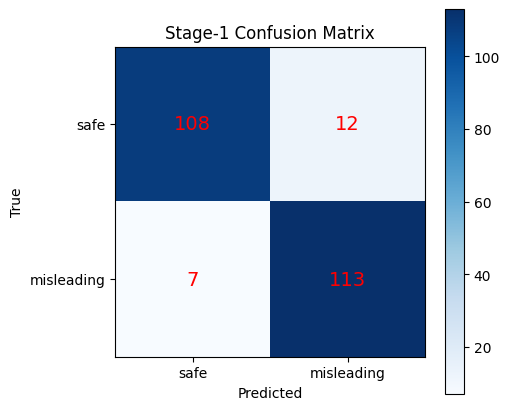


PORTION 5 COMPLETE ✅


In [5]:
# =========================================================
# PORTION 5 : TRAIN STAGE-1
# =========================================================

EPOCHS_STAGE1 = 5

best_f1_stage1 = 0

# =========================================================
# TRAINING LOOP
# =========================================================

for epoch in range(EPOCHS_STAGE1):

    print("\n" + "="*50)
    print(f"STAGE-1 EPOCH {epoch+1}/{EPOCHS_STAGE1}")
    print("="*50)

    # -----------------------------------------------------
    # TRAIN
    # -----------------------------------------------------

    train_loss, train_acc, train_f1 = \
        train_stage1_epoch()

    # -----------------------------------------------------
    # VALIDATE
    # -----------------------------------------------------

    val_loss, val_acc, val_f1, y_true, y_pred = \
        validate_stage1()

    # -----------------------------------------------------
    # PRINT
    # -----------------------------------------------------

    print("\nTRAIN")

    print(f"Loss : {train_loss:.4f}")

    print(f"Acc  : {train_acc:.4f}")

    print(f"F1   : {train_f1:.4f}")

    print("\nVALIDATION")

    print(f"Loss : {val_loss:.4f}")

    print(f"Acc  : {val_acc:.4f}")

    print(f"F1   : {val_f1:.4f}")

    # -----------------------------------------------------
    # SAVE BEST MODEL
    # -----------------------------------------------------

    if val_f1 > best_f1_stage1:

        best_f1_stage1 = val_f1

        torch.save(

            stage1_model.state_dict(),

            "best_stage1_model.pth"
        )

        print("\nBest Stage1 model saved ✅")

# =========================================================
# FINAL REPORT
# =========================================================

print("\n" + "="*60)
print("FINAL STAGE-1 CLASSIFICATION REPORT")
print("="*60)

print(

    classification_report(

        y_true,

        y_pred,

        target_names=[
            "safe",
            "misleading"
        ]
    )
)

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(5,5))

plt.imshow(cm, cmap="Blues")

plt.title("Stage-1 Confusion Matrix")

plt.colorbar()

plt.xticks([0,1], [
    "safe",
    "misleading"
])

plt.yticks([0,1], [
    "safe",
    "misleading"
])

for i in range(2):

    for j in range(2):

        plt.text(

            j,
            i,
            cm[i,j],

            ha="center",

            va="center",

            color="red",

            fontsize=14
        )

plt.xlabel("Predicted")

plt.ylabel("True")

plt.show()

print("\nPORTION 5 COMPLETE ✅")


STAGE-2 EPOCH 1/5


Loss: 0.6628: 100%|██████████| 170/170 [00:53<00:00,  3.16it/s]



TRAIN
Loss : 0.7814
Acc  : 0.7471
F1   : 0.7420

VALIDATION
Loss : 0.4425
Acc  : 0.8917
F1   : 0.8872

Best Stage2 model saved ✅

STAGE-2 EPOCH 2/5


Loss: 0.2449: 100%|██████████| 170/170 [00:52<00:00,  3.23it/s]



TRAIN
Loss : 0.3826
Acc  : 0.8956
F1   : 0.8956

VALIDATION
Loss : 0.3256
Acc  : 0.8917
F1   : 0.8872

STAGE-2 EPOCH 3/5


...


TRAIN
Loss : 0.2456
Acc  : 0.9265
F1   : 0.9265

VALIDATION
Loss : 0.3060
Acc  : 0.8833
F1   : 0.8799

STAGE-2 EPOCH 4/5


Loss: 0.0234: 100%|██████████| 170/170 [00:50<00:00,  3.35it/s]



TRAIN
Loss : 0.1834
Acc  : 0.9412
F1   : 0.9414

VALIDATION
Loss : 0.2331
Acc  : 0.8917
F1   : 0.8876

Best Stage2 model saved ✅

STAGE-2 EPOCH 5/5


Loss: 0.1025: 100%|██████████| 170/170 [00:49<00:00,  3.41it/s]



TRAIN
Loss : 0.1290
Acc  : 0.9647
F1   : 0.9649

VALIDATION
Loss : 0.2277
Acc  : 0.9083
F1   : 0.9051

Best Stage2 model saved ✅

FINAL STAGE-2 CLASSIFICATION REPORT
                                  precision    recall  f1-score   support

            identity_fabrication       0.93      0.87      0.90        30
         perception_manipulation       0.96      0.79      0.87        29
scientifically_unrealistic_scene       0.79      0.96      0.87        28
                 surreal_content       0.97      1.00      0.99        33

                        accuracy                           0.91       120
                       macro avg       0.91      0.91      0.91       120
                    weighted avg       0.92      0.91      0.91       120



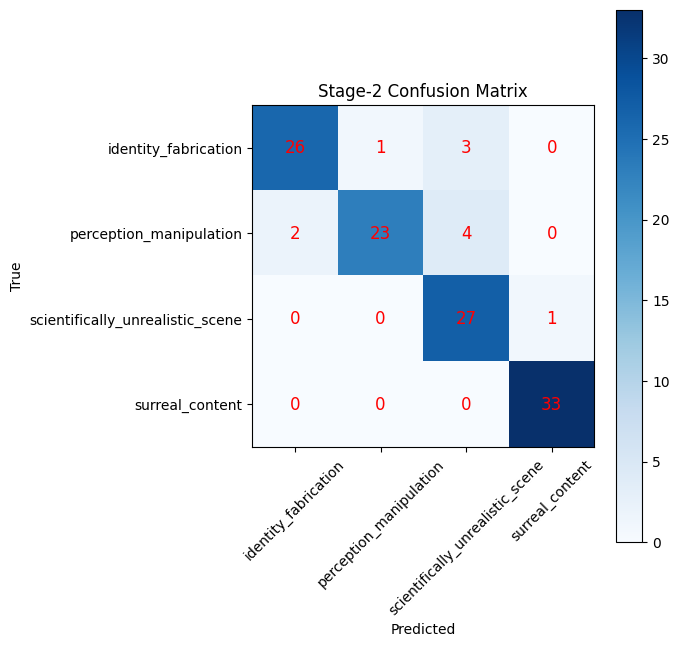


PORTION 6 COMPLETE ✅


In [6]:
# =========================================================
# PORTION 6 : TRAIN STAGE-2
# =========================================================

EPOCHS_STAGE2 = 5

best_f1_stage2 = 0

# =========================================================
# TRAINING LOOP
# =========================================================

for epoch in range(EPOCHS_STAGE2):

    print("\n" + "="*50)
    print(f"STAGE-2 EPOCH {epoch+1}/{EPOCHS_STAGE2}")
    print("="*50)

    # -----------------------------------------------------
    # TRAIN
    # -----------------------------------------------------

    train_loss, train_acc, train_f1 = \
        train_stage2_epoch()

    # -----------------------------------------------------
    # VALIDATE
    # -----------------------------------------------------

    val_loss, val_acc, val_f1, y_true, y_pred = \
        validate_stage2()

    # -----------------------------------------------------
    # PRINT
    # -----------------------------------------------------

    print("\nTRAIN")

    print(f"Loss : {train_loss:.4f}")

    print(f"Acc  : {train_acc:.4f}")

    print(f"F1   : {train_f1:.4f}")

    print("\nVALIDATION")

    print(f"Loss : {val_loss:.4f}")

    print(f"Acc  : {val_acc:.4f}")

    print(f"F1   : {val_f1:.4f}")

    # -----------------------------------------------------
    # SAVE BEST MODEL
    # -----------------------------------------------------

    if val_f1 > best_f1_stage2:

        best_f1_stage2 = val_f1

        torch.save(

            stage2_model.state_dict(),

            "best_stage2_model.pth"
        )

        print("\nBest Stage2 model saved ✅")

# =========================================================
# FINAL REPORT
# =========================================================

print("\n" + "="*60)
print("FINAL STAGE-2 CLASSIFICATION REPORT")
print("="*60)

print(

    classification_report(

        y_true,

        y_pred,

        target_names=[

            "identity_fabrication",

            "perception_manipulation",

            "scientifically_unrealistic_scene",

            "surreal_content"
        ]
    )
)

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7,7))

plt.imshow(cm, cmap="Blues")

plt.title("Stage-2 Confusion Matrix")

plt.colorbar()

labels = [

    "identity_fabrication",

    "perception_manipulation",

    "scientifically_unrealistic_scene",

    "surreal_content"
]

plt.xticks(
    np.arange(4),
    labels,
    rotation=45
)

plt.yticks(
    np.arange(4),
    labels
)

for i in range(4):

    for j in range(4):

        plt.text(

            j,
            i,
            cm[i,j],

            ha="center",

            va="center",

            color="red",

            fontsize=12
        )

plt.xlabel("Predicted")

plt.ylabel("True")

plt.tight_layout()

plt.show()

print("\nPORTION 6 COMPLETE ✅")

Best models loaded ✅

HIERARCHICAL PREDICTION
Final Label : identity_fabrication
Confidence  : 0.875

FRAME IMPORTANCE
Frame 01 | score=0.0542
Frame 02 | score=0.0712 <-- TOP
Frame 03 | score=0.0574
Frame 04 | score=0.0625
Frame 05 | score=0.0620
Frame 06 | score=0.0455
Frame 07 | score=0.0712 <-- TOP
Frame 08 | score=0.0586
Frame 09 | score=0.0621
Frame 10 | score=0.0556
Frame 11 | score=0.0725 <-- TOP
Frame 12 | score=0.0647
Frame 13 | score=0.0594
Frame 14 | score=0.0664
Frame 15 | score=0.0711
Frame 16 | score=0.0657


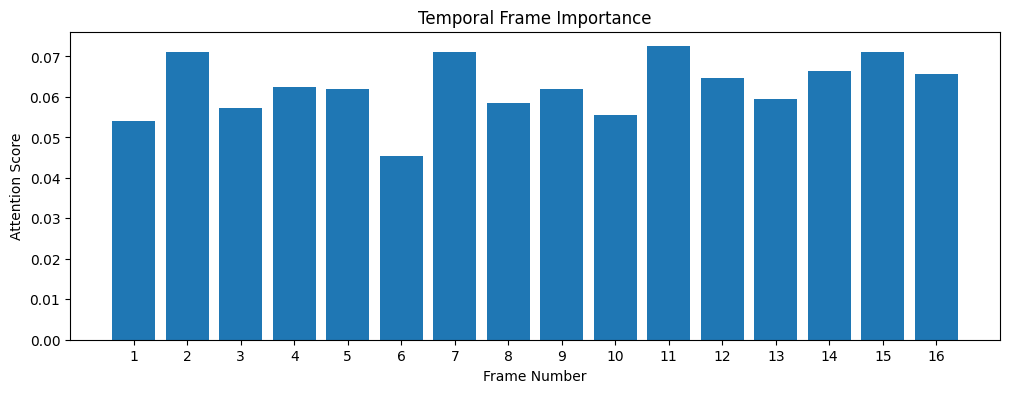


Top Frames:
[11  7  2]

PORTION 7 COMPLETE ✅


In [7]:
# =========================================================
# PORTION 7 : HIERARCHICAL PREDICTION + XAI PREP
# =========================================================

# =========================================================
# LOAD BEST MODELS
# =========================================================

stage1_model.load_state_dict(

    torch.load(
        "best_stage1_model.pth"
    )
)

stage2_model.load_state_dict(

    torch.load(
        "best_stage2_model.pth"
    )
)

stage1_model.eval()
stage2_model.eval()

print("Best models loaded ✅")

# =========================================================
# LABEL MAPS
# =========================================================

stage1_labels = {

    0: "safe",
    1: "misleading"
}

stage2_labels = {

    0: "identity_fabrication",

    1: "perception_manipulation",

    2: "scientifically_unrealistic_scene",

    3: "surreal_content"
}

# =========================================================
# HIERARCHICAL PREDICTION
# =========================================================

@torch.no_grad()

def hierarchical_predict(sample):

    # -----------------------------------------------------
    # INPUTS
    # -----------------------------------------------------

    frames = sample["frames"].unsqueeze(0).to(
        DEVICE
    )

    input_ids = tokenizer(

        [sample["text"]],

        padding=True,

        truncation=True,

        max_length=128,

        return_tensors="pt"
    )["input_ids"].to(DEVICE)

    attention_mask = tokenizer(

        [sample["text"]],

        padding=True,

        truncation=True,

        max_length=128,

        return_tensors="pt"
    )["attention_mask"].to(DEVICE)

    # =====================================================
    # STAGE-1
    # =====================================================

    logits1, weights1 = stage1_model(

        frames,

        input_ids,

        attention_mask
    )

    probs1 = torch.softmax(
        logits1,
        dim=1
    )[0]

    pred1 = torch.argmax(
        probs1
    ).item()

    conf1 = probs1[pred1].item()

    # =====================================================
    # SAFE
    # =====================================================

    if pred1 == 0:

        return {

            "stage1_label": "safe",

            "stage1_conf": conf1,

            "stage1_probs": probs1.cpu().numpy(),

            "attention_weights":

                weights1[0]
                .squeeze(-1)
                .cpu()
                .numpy(),

            "final_label": "safe",

            "final_conf": conf1
        }

    # =====================================================
    # STAGE-2
    # =====================================================

    logits2, weights2 = stage2_model(

        frames,

        input_ids,

        attention_mask
    )

    probs2 = torch.softmax(
        logits2,
        dim=1
    )[0]

    pred2 = torch.argmax(
        probs2
    ).item()

    conf2 = probs2[pred2].item()

    return {

        "stage1_label": "misleading",

        "stage1_conf": conf1,

        "stage1_probs": probs1.cpu().numpy(),

        "stage2_probs": probs2.cpu().numpy(),

        "attention_weights":

            weights2[0]
            .squeeze(-1)
            .cpu()
            .numpy(),

        "final_label":

            stage2_labels[pred2],

        "final_conf": conf2
    }

# =========================================================
# TOP-K FRAMES
# =========================================================

def get_top_frames(

    attention_weights,

    top_k=3
):

    idx = np.argsort(
        attention_weights
    )[::-1]

    return idx[:top_k]

# =========================================================
# VISUALIZE FRAME IMPORTANCE
# =========================================================

def show_frame_importance(

    sample,

    result
):

    scores = result[
        "attention_weights"
    ]

    top_idx = get_top_frames(
        scores,
        top_k=3
    )

    print("\n==============================")
    print("FRAME IMPORTANCE")
    print("==============================")

    for i in range(16):

        marker = ""

        if i in top_idx:

            marker = " <-- TOP"

        print(

            f"Frame {i+1:02d}"

            f" | score={scores[i]:.4f}"

            f"{marker}"
        )

    # -----------------------------------------------------
    # BARPLOT
    # -----------------------------------------------------

    plt.figure(figsize=(12,4))

    plt.bar(

        np.arange(1,17),

        scores
    )

    plt.xticks(np.arange(1,17))

    plt.xlabel("Frame Number")

    plt.ylabel("Attention Score")

    plt.title(
        "Temporal Frame Importance"
    )

    plt.show()

    return top_idx

# =========================================================
# TEST ON MISLEADING SAMPLE
# =========================================================

mis_idx = None

for i in range(len(test_dataset)):

    if test_dataset[i]["label_stage1"] == 1:

        mis_idx = i
        break

sample = test_dataset[mis_idx]

result = hierarchical_predict(
    sample
)

# =========================================================
# PRINT RESULTS
# =========================================================

print("\n==============================")
print("HIERARCHICAL PREDICTION")
print("==============================")

print(

    "Final Label :",

    result["final_label"]
)

print(

    "Confidence  :",

    round(
        result["final_conf"],
        4
    )
)

# =========================================================
# FRAME IMPORTANCE
# =========================================================

top_idx = show_frame_importance(

    sample,

    result
)

print("\nTop Frames:")
print(top_idx + 1)

print("\nPORTION 7 COMPLETE ✅")

In [8]:
# =========================================================
# PREDICT BY VIDEO ID
# =========================================================

def predict_by_video_id(

    video_id,

    split="test"
):

    # -----------------------------------------------------
    # SELECT DATASET
    # -----------------------------------------------------

    if split == "train":

        dataset = train_dataset

    elif split == "val":

        dataset = val_dataset

    else:

        dataset = test_dataset

    # -----------------------------------------------------
    # FIND VIDEO
    # -----------------------------------------------------

    found = False

    for i in range(len(dataset)):

        sample = dataset[i]

        if sample["video_id"] == video_id:

            found = True
            break

    # -----------------------------------------------------
    # NOT FOUND
    # -----------------------------------------------------

    if found == False:

        print("Video ID not found ❌")
        return None

    # -----------------------------------------------------
    # TRUE LABELS
    # -----------------------------------------------------

    true_stage1 = sample[
        "label_stage1"
    ].item()

    true_stage2 = sample[
        "label_stage2"
    ].item()

    print("\n==============================")
    print("VIDEO INFORMATION")
    print("==============================")

    print("Video ID:")
    print(video_id)

    print("\nTRUE STAGE1:")
    print(
        stage1_labels[true_stage1]
    )

    if true_stage2 != -1:

        print("\nTRUE STAGE2:")
        print(
            stage2_labels[true_stage2]
        )

    # -----------------------------------------------------
    # PREDICT
    # -----------------------------------------------------

    result = hierarchical_predict(
        sample
    )

    # -----------------------------------------------------
    # RESULTS
    # -----------------------------------------------------

    print("\n==============================")
    print("MODEL PREDICTION")
    print("==============================")

    print(

        "Predicted Label :",

        result["final_label"]
    )

    print(

        "Confidence      :",

        round(
            result["final_conf"],
            4
        )
    )

    # -----------------------------------------------------
    # FRAME IMPORTANCE
    # -----------------------------------------------------

    top_idx = show_frame_importance(

        sample,

        result
    )

    print("\nTop Frames:")
    print(top_idx + 1)

    return sample, result, top_idx


VIDEO INFORMATION
Video ID:
TEST_PM_046

TRUE STAGE1:
misleading

TRUE STAGE2:
perception_manipulation

MODEL PREDICTION
Predicted Label : perception_manipulation
Confidence      : 0.8295

FRAME IMPORTANCE
Frame 01 | score=0.0044
Frame 02 | score=0.0051
Frame 03 | score=0.0491
Frame 04 | score=0.0950 <-- TOP
Frame 05 | score=0.0612
Frame 06 | score=0.0465
Frame 07 | score=0.0300
Frame 08 | score=0.0565
Frame 09 | score=0.0571
Frame 10 | score=0.0991 <-- TOP
Frame 11 | score=0.1146 <-- TOP
Frame 12 | score=0.0719
Frame 13 | score=0.0624
Frame 14 | score=0.0821
Frame 15 | score=0.0843
Frame 16 | score=0.0807


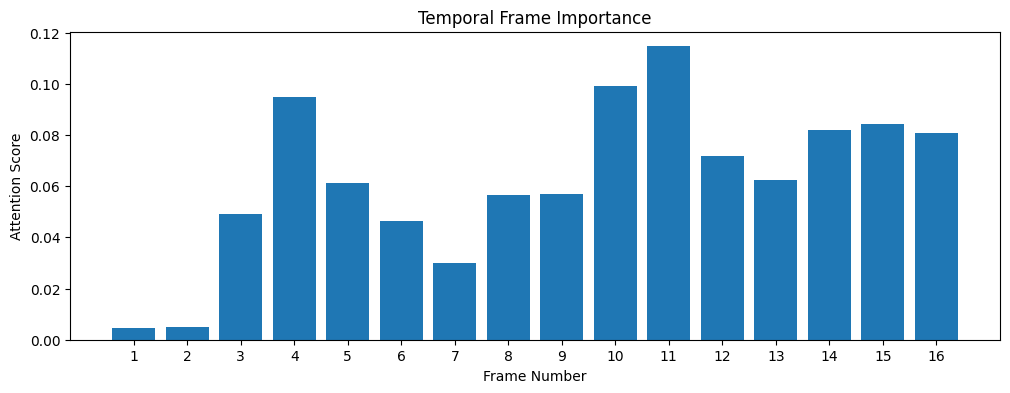


Top Frames:
[11 10  4]


In [9]:
sample, result, top_idx = predict_by_video_id(
    "TEST_PM_046",
    split="test"
)


VIDEO INFORMATION
Video ID:
TEST_IF_023

TRUE STAGE1:
misleading

TRUE STAGE2:
identity_fabrication

MODEL PREDICTION
Predicted Label : identity_fabrication
Confidence      : 0.981

FRAME IMPORTANCE
Frame 01 | score=0.0316
Frame 02 | score=0.0648
Frame 03 | score=0.0615
Frame 04 | score=0.0638
Frame 05 | score=0.0636
Frame 06 | score=0.0669 <-- TOP
Frame 07 | score=0.0614
Frame 08 | score=0.0636
Frame 09 | score=0.0645
Frame 10 | score=0.0624
Frame 11 | score=0.0716 <-- TOP
Frame 12 | score=0.0665
Frame 13 | score=0.0677 <-- TOP
Frame 14 | score=0.0650
Frame 15 | score=0.0599
Frame 16 | score=0.0653


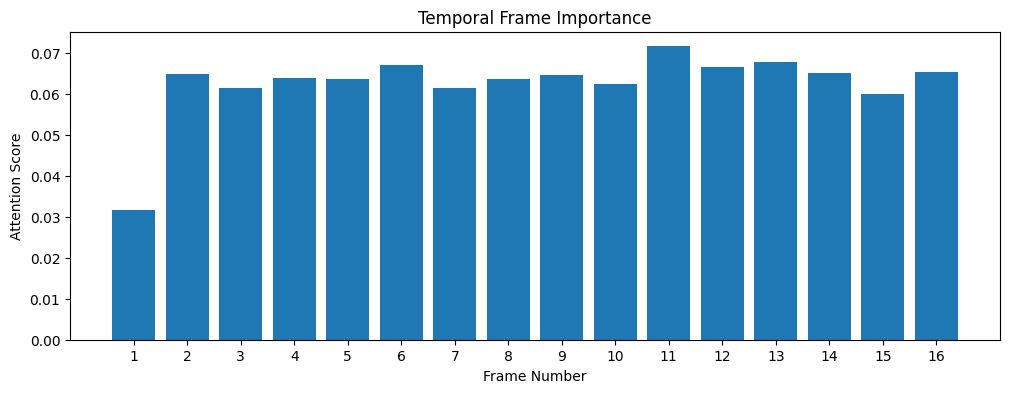


Top Frames:
[11 13  6]


In [10]:
sample, result, top_idx = predict_by_video_id(
    "TEST_IF_023",
    split="test"
)

GradCAM hooks registered ✅


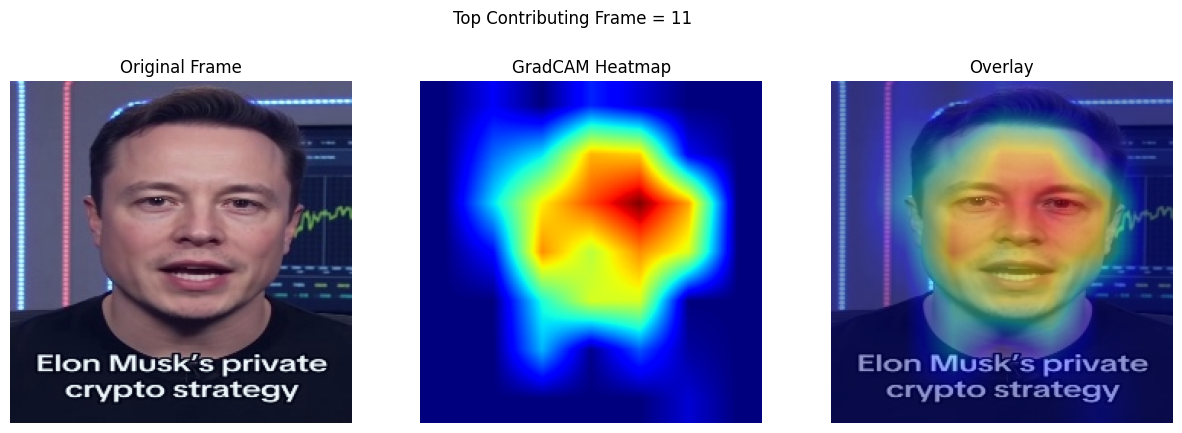


PORTION 8 COMPLETE ✅


In [11]:
# =========================================================
# PORTION 8 : TRUE GRADCAM
# =========================================================

import matplotlib.cm as cm

# =========================================================
# HOOK STORAGE
# =========================================================

gradients = None
activations = None

# =========================================================
# TARGET LAYER
# =========================================================

target_layer = clip_model.vision_model.embeddings.patch_embedding

# =========================================================
# HOOK FUNCTIONS
# =========================================================

def forward_hook(module, inp, out):

    global activations

    activations = out

def backward_hook(module, grad_in, grad_out):

    global gradients

    gradients = grad_out[0]

# =========================================================
# REGISTER HOOKS
# =========================================================

forward_handle = target_layer.register_forward_hook(
    forward_hook
)

backward_handle = target_layer.register_full_backward_hook(
    backward_hook
)

print("GradCAM hooks registered ✅")

# =========================================================
# GENERATE GRADCAM
# =========================================================

def generate_gradcam(

    sample,

    frame_index
):

    global gradients
    global activations

    gradients = None
    activations = None

    # -----------------------------------------------------
    # MODELS
    # -----------------------------------------------------

    stage1_model.eval()
    stage2_model.eval()

    # -----------------------------------------------------
    # FRAME
    # -----------------------------------------------------

    frame = sample["frames"][
        frame_index
    ].unsqueeze(0).to(DEVICE)

    frame.requires_grad = True

    # -----------------------------------------------------
    # TEXT
    # -----------------------------------------------------

    toks = tokenizer(

        [sample["text"]],

        padding=True,

        truncation=True,

        max_length=128,

        return_tensors="pt"
    )

    input_ids = toks["input_ids"].to(
        DEVICE
    )

    attention_mask = toks[
        "attention_mask"
    ].to(DEVICE)

    # =====================================================
    # CLIP FEATURES
    # =====================================================

    outputs = clip_model.vision_model(
        pixel_values=frame
    )

    if hasattr(outputs, "pooler_output"):

        video_feat = outputs.pooler_output

    else:

        video_feat = outputs.last_hidden_state.mean(
            dim=1
        )

    # =====================================================
    # TEXT FEATURES
    # =====================================================

    with torch.no_grad():

        txt_out = text_model(

            input_ids=input_ids,

            attention_mask=attention_mask
        )

    text_feat = txt_out.last_hidden_state[
        :,
        0,
        :
    ]

    # =====================================================
    # STAGE-1
    # =====================================================

    fusion1 = torch.cat([

        video_feat,

        text_feat

    ], dim=1)

    logits1 = stage1_model.classifier(
        fusion1
    )

    probs1 = torch.softmax(
        logits1,
        dim=1
    )

    pred1 = torch.argmax(
        probs1,
        dim=1
    ).item()

    # =====================================================
    # SAFE
    # =====================================================

    if pred1 == 0:

        score = logits1[:,0]

    # =====================================================
    # MISLEADING → STAGE-2
    # =====================================================

    else:

        fusion2 = torch.cat([

            video_feat,

            text_feat

        ], dim=1)

        logits2 = stage2_model.classifier(
            fusion2
        )

        pred2 = torch.argmax(
            logits2,
            dim=1
        )

        score = logits2[:, pred2]

    # =====================================================
    # BACKPROP
    # =====================================================

    clip_model.zero_grad()

    stage1_model.zero_grad()

    stage2_model.zero_grad()

    score.backward()

    # =====================================================
    # CHECK
    # =====================================================

    if gradients is None:

        print("No gradients ❌")
        return None

    # =====================================================
    # FEATURE MAPS
    # =====================================================

    grads = gradients

    acts = activations

    # shape:
    # (1,768,7,7)

    weights = grads.mean(
        dim=(2,3),
        keepdim=True
    )

    cam = (weights * acts).sum(dim=1)

    cam = F.relu(cam)

    cam = cam.squeeze().detach().cpu().numpy()

    # -----------------------------------------------------
    # NORMALIZE
    # -----------------------------------------------------

    cam = cam - cam.min()

    cam = cam / (cam.max() + 1e-8)

    return cam

# =========================================================
# OVERLAY HEATMAP
# =========================================================

def overlay_heatmap(

    img_tensor,

    cam
):

    # -----------------------------------------------------
    # IMAGE
    # -----------------------------------------------------

    img = img_tensor.permute(
        1,
        2,
        0
    ).cpu().numpy()

    img = img - img.min()

    img = img / (img.max() + 1e-8)

    # -----------------------------------------------------
    # UPSAMPLE
    # -----------------------------------------------------

    cam = cv2.resize(
        cam,
        (224,224)
    )

    # -----------------------------------------------------
    # RED HEATMAP
    # -----------------------------------------------------

    heatmap = cm.jet(cam)[:,:,:3]

    # -----------------------------------------------------
    # OVERLAY
    # -----------------------------------------------------

    overlay = (

        0.6 * img
        +
        0.4 * heatmap
    )

    overlay = np.clip(
        overlay,
        0,
        1
    )

    return img, heatmap, overlay

# =========================================================
# SHOW TOP FRAME GRADCAM
# =========================================================

def show_top_gradcam(

    sample,

    top_idx
):

    # -----------------------------------------------------
    # TOP FRAME
    # -----------------------------------------------------

    idx = top_idx[0]

    frame = sample["frames"][idx]

    # -----------------------------------------------------
    # CAM
    # -----------------------------------------------------

    cam = generate_gradcam(

        sample,

        idx
    )

    if cam is None:

        return

    img, heatmap, overlay = overlay_heatmap(

        frame,

        cam
    )

    # =====================================================
    # PLOT
    # =====================================================

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)

    plt.imshow(img)

    plt.title("Original Frame")

    plt.axis("off")

    # -----------------------------------------------------

    plt.subplot(1,3,2)

    plt.imshow(heatmap)

    plt.title("GradCAM Heatmap")

    plt.axis("off")

    # -----------------------------------------------------

    plt.subplot(1,3,3)

    plt.imshow(overlay)

    plt.title("Overlay")

    plt.axis("off")

    plt.suptitle(

        f"Top Contributing Frame = {idx+1}"
    )

    plt.show()

# =========================================================
# RUN
# =========================================================

show_top_gradcam(

    sample,

    top_idx
)

print("\nPORTION 8 COMPLETE ✅")

# 1. GRAD-CAM

In [12]:
# =========================================================
# THESIS READY VIDEO-ID PREDICTOR
# =========================================================

def predict_by_video_id(video_id):

    # -----------------------------------------------------
    # AUTO SPLIT DETECTION
    # -----------------------------------------------------

    if video_id.startswith("TRAIN"):

        dataset = train_dataset
        split = "train"

    elif video_id.startswith("VAL"):

        dataset = val_dataset
        split = "val"

    else:

        dataset = test_dataset
        split = "test"

    # -----------------------------------------------------
    # FIND VIDEO
    # -----------------------------------------------------

    sample = None

    for i in range(len(dataset)):

        s = dataset[i]

        if s["video_id"] == video_id:

            sample = s
            break

    # -----------------------------------------------------
    # NOT FOUND
    # -----------------------------------------------------

    if sample is None:

        print("Video ID not found ❌")
        return None

    # -----------------------------------------------------
    # TRUE LABELS
    # -----------------------------------------------------

    true_stage1 = sample[
        "label_stage1"
    ].item()

    true_stage2 = sample[
        "label_stage2"
    ].item()

    print("\n" + "="*40)
    print("VIDEO INFORMATION")
    print("="*40)

    print("Video ID:")
    print(video_id)

    print("\nDataset Split:")
    print(split)

    print("\nTRUE STAGE1:")
    print(
        stage1_labels[true_stage1]
    )

    if true_stage2 != -1:

        print("\nTRUE STAGE2:")
        print(
            stage2_labels[true_stage2]
        )

    # -----------------------------------------------------
    # PREDICT
    # -----------------------------------------------------

    result = hierarchical_predict(
        sample
    )

    print("\n" + "="*40)
    print("MODEL PREDICTION")
    print("="*40)

    print(
        "Predicted Label :",
        result["final_label"]
    )

    print(
        "Confidence      :",
        round(
            result["final_conf"],
            4
        )
    )

    # -----------------------------------------------------
    # TEMPORAL ATTENTION
    # -----------------------------------------------------

    top_idx = show_frame_importance(

        sample,

        result
    )

    print("\nTop Frames:")
    print(top_idx + 1)

    # -----------------------------------------------------
    # TRUE GRADCAM
    # -----------------------------------------------------

    show_top_gradcam(

        sample,

        top_idx
    )

    return sample, result, top_idx 


VIDEO INFORMATION
Video ID:
TEST_PM_046

Dataset Split:
test

TRUE STAGE1:
misleading

TRUE STAGE2:
perception_manipulation

MODEL PREDICTION
Predicted Label : perception_manipulation
Confidence      : 0.8295

FRAME IMPORTANCE
Frame 01 | score=0.0044
Frame 02 | score=0.0051
Frame 03 | score=0.0491
Frame 04 | score=0.0950 <-- TOP
Frame 05 | score=0.0612
Frame 06 | score=0.0465
Frame 07 | score=0.0300
Frame 08 | score=0.0565
Frame 09 | score=0.0571
Frame 10 | score=0.0991 <-- TOP
Frame 11 | score=0.1146 <-- TOP
Frame 12 | score=0.0719
Frame 13 | score=0.0624
Frame 14 | score=0.0821
Frame 15 | score=0.0843
Frame 16 | score=0.0807


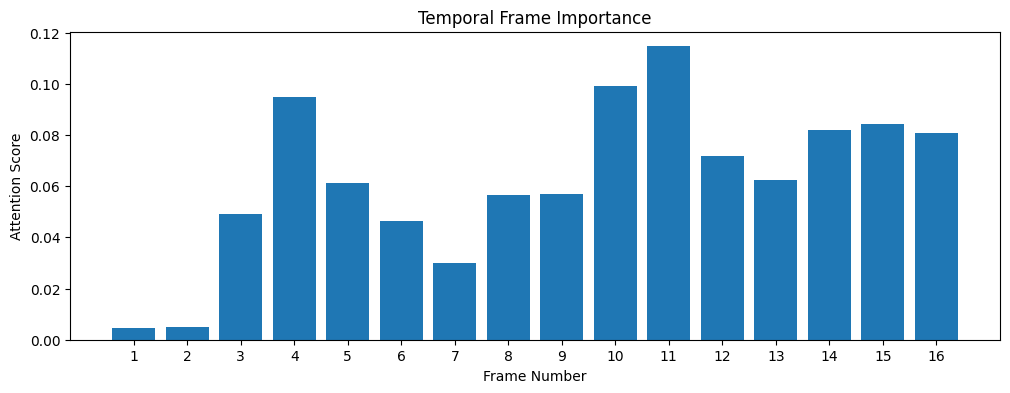


Top Frames:
[11 10  4]


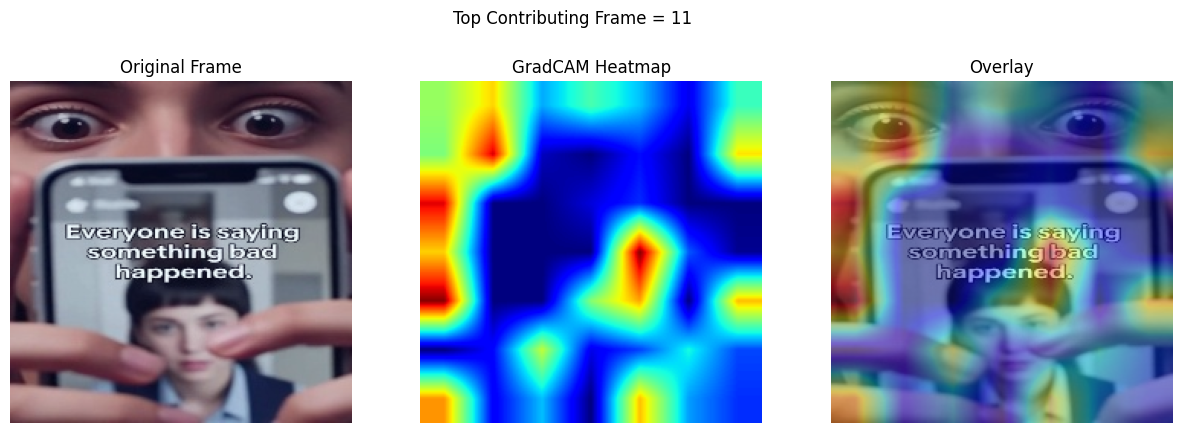

({'video_id': 'TEST_PM_046',
  'frames': tensor([[[[-1.6609, -1.6463, -1.6171,  ..., -1.6609, -1.6609, -1.6609],
            [-1.6609, -1.6463, -1.6171,  ..., -1.6463, -1.6463, -1.6463],
            [-1.6609, -1.6609, -1.6171,  ..., -1.6463, -1.6463, -1.6463],
            ...,
            [-1.0185, -1.0185, -1.0185,  ..., -1.2229, -1.1937, -1.1937],
            [-1.0331, -1.0331, -1.0331,  ..., -1.2083, -1.1791, -1.1791],
            [-0.9456, -0.9456, -0.9456,  ..., -1.1937, -1.1791, -1.1645]],
  
           [[-1.6470, -1.6320, -1.6320,  ..., -1.6170, -1.6170, -1.6170],
            [-1.6470, -1.6320, -1.6320,  ..., -1.6020, -1.6020, -1.6020],
            [-1.6470, -1.6470, -1.6320,  ..., -1.6020, -1.6020, -1.6020],
            ...,
            [-1.3019, -1.3019, -1.3019,  ..., -1.4669, -1.4369, -1.4369],
            [-1.2869, -1.2869, -1.2869,  ..., -1.4519, -1.4219, -1.4219],
            [-1.1968, -1.1968, -1.1968,  ..., -1.4369, -1.4219, -1.4069]],
  
           [[-1.3665, -1.3522, 

In [13]:
predict_by_video_id("TEST_PM_046")


VIDEO INFORMATION
Video ID:
TEST_IF_023

Dataset Split:
test

TRUE STAGE1:
misleading

TRUE STAGE2:
identity_fabrication

MODEL PREDICTION
Predicted Label : identity_fabrication
Confidence      : 0.981

FRAME IMPORTANCE
Frame 01 | score=0.0316
Frame 02 | score=0.0648
Frame 03 | score=0.0615
Frame 04 | score=0.0638
Frame 05 | score=0.0636
Frame 06 | score=0.0669 <-- TOP
Frame 07 | score=0.0614
Frame 08 | score=0.0636
Frame 09 | score=0.0645
Frame 10 | score=0.0624
Frame 11 | score=0.0716 <-- TOP
Frame 12 | score=0.0665
Frame 13 | score=0.0677 <-- TOP
Frame 14 | score=0.0650
Frame 15 | score=0.0599
Frame 16 | score=0.0653


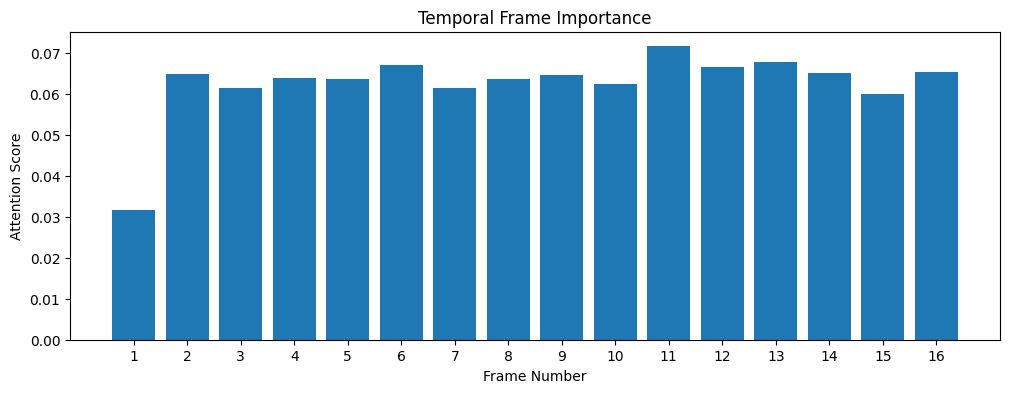


Top Frames:
[11 13  6]


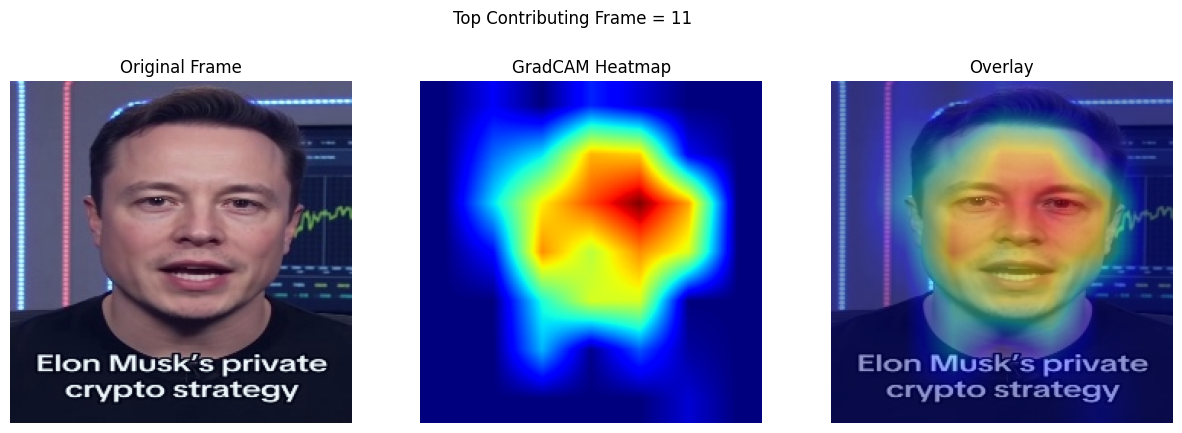

({'video_id': 'TEST_IF_023',
  'frames': tensor([[[[-5.6599e-01, -5.3680e-01, -4.3461e-01,  ..., -4.9300e-01,
             -4.2001e-01, -3.9081e-01],
            [-6.6818e-01, -6.0979e-01, -6.9738e-01,  ..., -4.6381e-01,
             -4.2001e-01, -4.2001e-01],
            [-6.2439e-01, -6.3899e-01, -6.0979e-01,  ..., -4.9300e-01,
             -4.4921e-01, -4.4921e-01],
            ...,
            [-1.5879e+00, -1.5879e+00, -1.5879e+00,  ..., -1.5879e+00,
             -1.5879e+00, -1.5879e+00],
            [-1.5879e+00, -1.5879e+00, -1.5879e+00,  ..., -1.5879e+00,
             -1.5879e+00, -1.5879e+00],
            [-1.5879e+00, -1.5879e+00, -1.5879e+00,  ..., -1.5879e+00,
             -1.5879e+00, -1.5879e+00]],
  
           [[-4.9144e-01, -4.6143e-01, -3.4137e-01,  ..., -4.4642e-01,
             -4.7644e-01, -4.9144e-01],
            [-5.9650e-01, -5.3647e-01, -6.2651e-01,  ..., -4.4642e-01,
             -4.6143e-01, -4.7644e-01],
            [-5.8149e-01, -5.9650e-01, -5.6648e-01, 

In [14]:
predict_by_video_id("TEST_IF_023")


VIDEO INFORMATION
Video ID:
TEST_SC_023

Dataset Split:
test

TRUE STAGE1:
misleading

TRUE STAGE2:
surreal_content

MODEL PREDICTION
Predicted Label : surreal_content
Confidence      : 0.8908

FRAME IMPORTANCE
Frame 01 | score=0.2153 <-- TOP
Frame 02 | score=0.0418
Frame 03 | score=0.0385
Frame 04 | score=0.0357
Frame 05 | score=0.0488
Frame 06 | score=0.0566
Frame 07 | score=0.0466
Frame 08 | score=0.0737 <-- TOP
Frame 09 | score=0.0671
Frame 10 | score=0.0433
Frame 11 | score=0.0475
Frame 12 | score=0.0723
Frame 13 | score=0.0822 <-- TOP
Frame 14 | score=0.0486
Frame 15 | score=0.0430
Frame 16 | score=0.0391


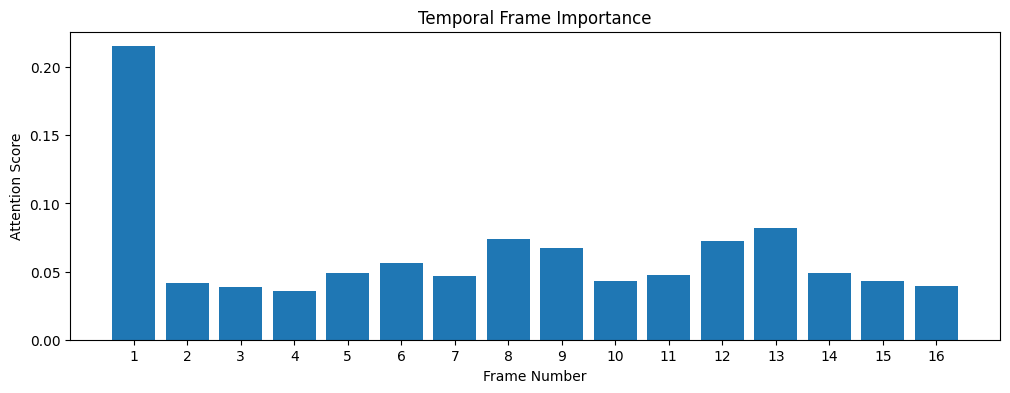


Top Frames:
[ 1 13  8]


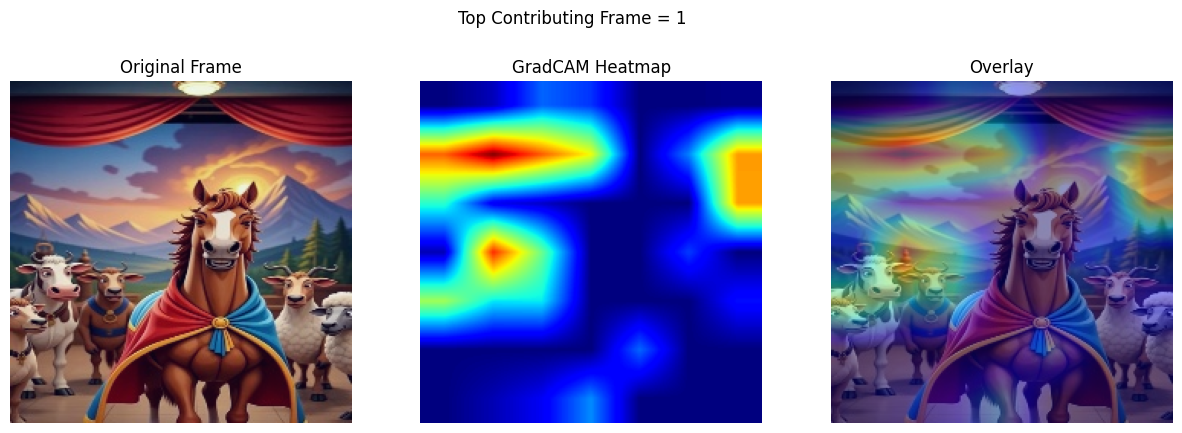

({'video_id': 'TEST_SC_023',
  'frames': tensor([[[[-1.6317, -1.6317, -1.6463,  ..., -1.5879, -1.5733, -1.5733],
            [-1.6025, -1.6171, -1.6025,  ..., -1.5587, -1.5295, -1.5441],
            [-1.5733, -1.5879, -1.5587,  ..., -1.5003, -1.4857, -1.4857],
            ...,
            [-0.8580, -0.6682, -0.4492,  ..., -1.4419, -1.3981, -1.5295],
            [-0.9456, -0.8726, -0.5368,  ..., -0.6536, -0.6244, -0.5806],
            [ 0.2661, -1.0185, -0.5368,  ..., -0.5514, -0.5660, -0.5952]],
  
           [[-1.4219, -1.4219, -1.4369,  ..., -1.3919, -1.3769, -1.3769],
            [-1.4219, -1.4069, -1.4219,  ..., -1.3619, -1.3619, -1.3469],
            [-1.4219, -1.4069, -1.4069,  ..., -1.3169, -1.3319, -1.3019],
            ...,
            [-1.3619, -1.1518, -0.9867,  ..., -1.6170, -1.5720, -1.7071],
            [-1.4369, -1.3469, -1.0317,  ..., -0.9867, -0.9567, -0.9267],
            [-0.1463, -1.4970, -1.0467,  ..., -0.9117, -1.0017, -1.0317]],
  
           [[-1.1105, -1.1105, 

In [15]:
predict_by_video_id("TEST_SC_023")


VIDEO INFORMATION
Video ID:
TEST_SUS_039

Dataset Split:
test

TRUE STAGE1:
misleading

TRUE STAGE2:
scientifically_unrealistic_scene

MODEL PREDICTION
Predicted Label : scientifically_unrealistic_scene
Confidence      : 0.8487

FRAME IMPORTANCE
Frame 01 | score=0.0169
Frame 02 | score=0.0182
Frame 03 | score=0.0272
Frame 04 | score=0.0186
Frame 05 | score=0.0182
Frame 06 | score=0.0655
Frame 07 | score=0.0903
Frame 08 | score=0.0853
Frame 09 | score=0.0985 <-- TOP
Frame 10 | score=0.0818
Frame 11 | score=0.0703
Frame 12 | score=0.1553 <-- TOP
Frame 13 | score=0.1147 <-- TOP
Frame 14 | score=0.0942
Frame 15 | score=0.0278
Frame 16 | score=0.0171


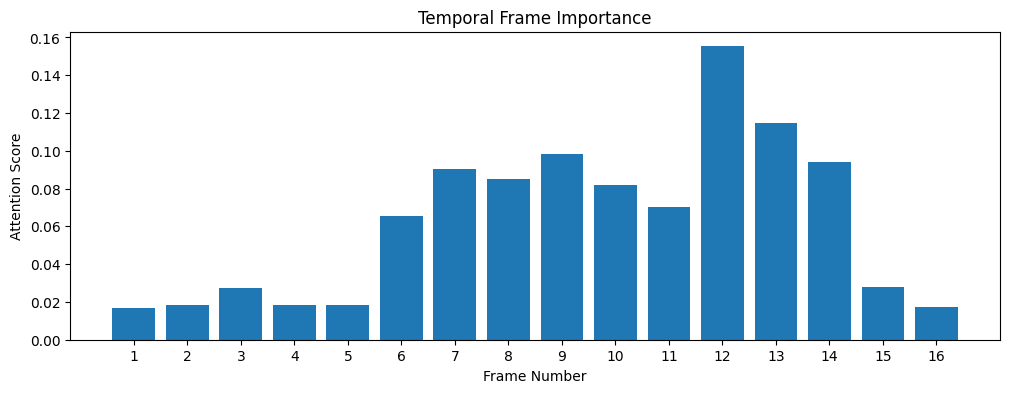


Top Frames:
[12 13  9]


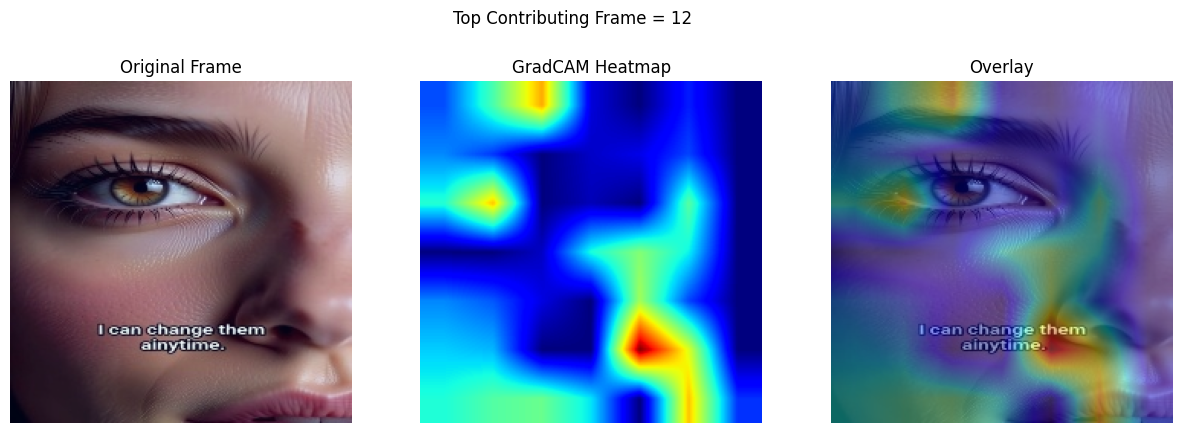

({'video_id': 'TEST_SUS_039',
  'frames': tensor([[[[-1.0039e+00, -1.7777e+00, -1.7339e+00,  ...,  1.2296e+00,
              1.3172e+00,  1.2734e+00],
            [-1.2813e+00, -1.7631e+00, -1.7193e+00,  ...,  1.1712e+00,
              1.2588e+00,  1.2734e+00],
            [-1.6025e+00, -1.7193e+00, -1.7047e+00,  ...,  1.4924e+00,
              1.4194e+00,  1.1566e+00],
            ...,
            [-1.7193e+00, -1.7193e+00, -1.7193e+00,  ...,  1.0544e+00,
              1.0398e+00,  1.0252e+00],
            [-1.6901e+00, -1.6901e+00, -1.7193e+00,  ...,  1.1566e+00,
              1.1858e+00,  1.0836e+00],
            [-1.6901e+00, -1.6901e+00, -1.7047e+00,  ...,  1.6822e+00,
              1.6822e+00,  1.4486e+00]],
  
           [[-9.7169e-01, -1.7521e+00, -1.7221e+00,  ...,  7.8422e-01,
              8.7426e-01,  8.2924e-01],
            [-1.2568e+00, -1.7521e+00, -1.7071e+00,  ...,  7.2418e-01,
              8.1423e-01,  8.2924e-01],
            [-1.5870e+00, -1.7071e+00, -1.6921e+00,

In [16]:
predict_by_video_id("TEST_SUS_039")


VIDEO INFORMATION
Video ID:
TEST_SAFE_055

Dataset Split:
test

TRUE STAGE1:
safe

MODEL PREDICTION
Predicted Label : safe
Confidence      : 0.7681

FRAME IMPORTANCE
Frame 01 | score=0.0613
Frame 02 | score=0.0637
Frame 03 | score=0.0659
Frame 04 | score=0.0721 <-- TOP
Frame 05 | score=0.0930 <-- TOP
Frame 06 | score=0.0650
Frame 07 | score=0.0573
Frame 08 | score=0.0429
Frame 09 | score=0.0669
Frame 10 | score=0.0601
Frame 11 | score=0.0537
Frame 12 | score=0.0617
Frame 13 | score=0.0747 <-- TOP
Frame 14 | score=0.0623
Frame 15 | score=0.0432
Frame 16 | score=0.0560


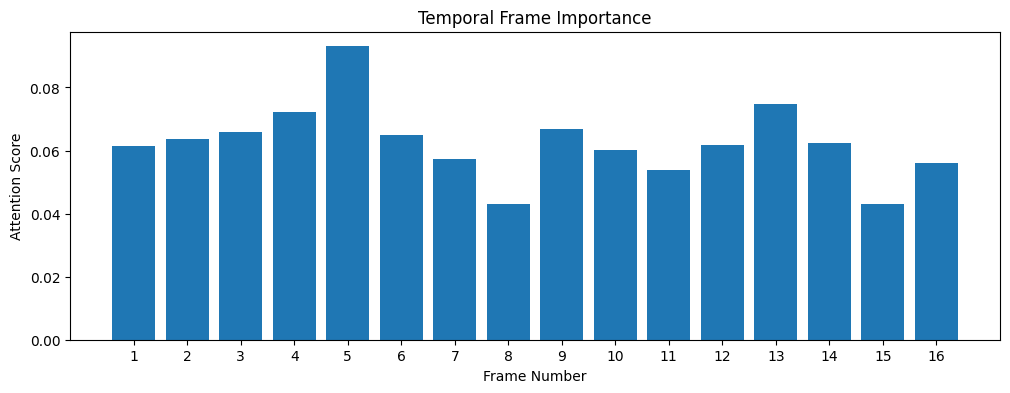


Top Frames:
[ 5 13  4]


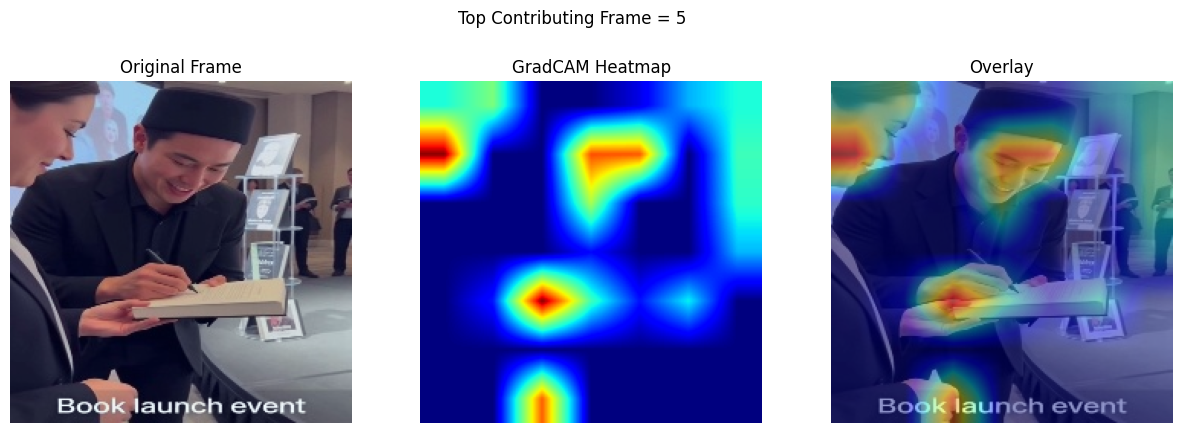

({'video_id': 'TEST_SAFE_055',
  'frames': tensor([[[[-1.1499e+00, -1.1499e+00, -1.1645e+00,  ...,  3.9750e-01,
              3.8290e-01,  3.9750e-01],
            [-1.2521e+00, -1.2521e+00, -1.2667e+00,  ...,  3.8290e-01,
              3.6830e-01,  3.6830e-01],
            [-1.3251e+00, -1.3105e+00, -1.2959e+00,  ...,  3.9750e-01,
              4.7049e-01,  3.9750e-01],
            ...,
            [-1.4273e+00, -1.4273e+00, -1.4419e+00,  ..., -3.4702e-01,
             -3.4702e-01, -3.4702e-01],
            [-1.4419e+00, -1.4419e+00, -1.4419e+00,  ..., -3.4702e-01,
             -3.6162e-01, -3.6162e-01],
            [-1.4273e+00, -1.4273e+00, -1.4273e+00,  ..., -3.6162e-01,
             -3.6162e-01, -3.7622e-01]],
  
           [[-1.2718e+00, -1.2718e+00, -1.2869e+00,  ...,  2.1392e-01,
              1.9891e-01,  2.1392e-01],
            [-1.3769e+00, -1.3769e+00, -1.3919e+00,  ...,  1.9891e-01,
              1.8391e-01,  1.8391e-01],
            [-1.4970e+00, -1.4820e+00, -1.4669e+00

In [17]:
predict_by_video_id("TEST_SAFE_055")

# 2. SCORE-CAM

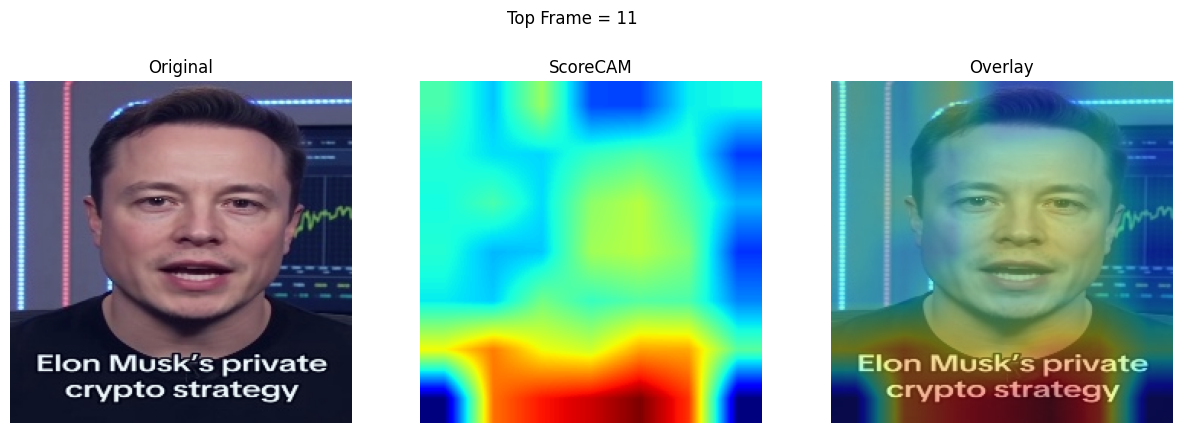

PORTION 9 COMPLETE ✅


In [18]:
# =========================================================
# PORTION 9 : SCORE-CAM
# =========================================================

# =========================================================
# SCORECAM
# =========================================================

def generate_scorecam(

    sample,

    frame_index
):

    stage1_model.eval()
    stage2_model.eval()

    # -----------------------------------------------------
    # FRAME
    # -----------------------------------------------------

    frame = sample["frames"][
        frame_index
    ].unsqueeze(0).to(DEVICE)

    # -----------------------------------------------------
    # TEXT
    # -----------------------------------------------------

    toks = tokenizer(

        [sample["text"]],

        padding=True,

        truncation=True,

        max_length=128,

        return_tensors="pt"
    )

    input_ids = toks["input_ids"].to(
        DEVICE
    )

    attention_mask = toks[
        "attention_mask"
    ].to(DEVICE)

    # =====================================================
    # ACTIVATIONS
    # =====================================================

    with torch.no_grad():

        outputs = clip_model.vision_model(
            pixel_values=frame
        )

    acts = activations.squeeze(0)

    # shape:
    # (768,7,7)

    scorecam = np.zeros((7,7))

    # =====================================================
    # LOOP MAPS
    # =====================================================

    for k in range(0, acts.shape[0], 8):

        fmap = acts[k]

        fmap = fmap.detach().cpu().numpy()

        fmap = np.maximum(fmap, 0)

        fmap = fmap - fmap.min()

        fmap = fmap / (fmap.max() + 1e-8)

        # -------------------------------------------------
        # UPSAMPLE
        # -------------------------------------------------

        mask = cv2.resize(
            fmap,
            (224,224)
        )

        mask_tensor = torch.tensor(
            mask
        ).float().to(DEVICE)

        masked_frame = frame * mask_tensor

        # =================================================
        # FORWARD
        # =================================================

        with torch.no_grad():

            out = clip_model.vision_model(
                pixel_values=masked_frame
            )

            if hasattr(out, "pooler_output"):

                vid_feat = out.pooler_output

            else:

                vid_feat = out.last_hidden_state.mean(
                    dim=1
                )

            txt_out = text_model(

                input_ids=input_ids,

                attention_mask=attention_mask
            )

            txt_feat = txt_out.last_hidden_state[
                :,
                0,
                :
            ]

            # ---------------------------------------------
            # STAGE1
            # ---------------------------------------------

            fusion1 = torch.cat([

                vid_feat,
                txt_feat

            ], dim=1)

            logits1 = stage1_model.classifier(
                fusion1
            )

            probs1 = torch.softmax(
                logits1,
                dim=1
            )

            pred1 = torch.argmax(
                probs1,
                dim=1
            ).item()

            # ---------------------------------------------
            # SAFE
            # ---------------------------------------------

            if pred1 == 0:

                score = probs1[
                    0,
                    0
                ].item()

            # ---------------------------------------------
            # STAGE2
            # ---------------------------------------------

            else:

                fusion2 = torch.cat([

                    vid_feat,
                    txt_feat

                ], dim=1)

                logits2 = stage2_model.classifier(
                    fusion2
                )

                probs2 = torch.softmax(
                    logits2,
                    dim=1
                )

                pred2 = torch.argmax(
                    probs2,
                    dim=1
                ).item()

                score = probs2[
                    0,
                    pred2
                ].item()

        scorecam += score * fmap

    # =====================================================
    # NORMALIZE
    # =====================================================

    scorecam = np.maximum(
        scorecam,
        0
    )

    scorecam = scorecam - scorecam.min()

    scorecam = scorecam / (
        scorecam.max() + 1e-8
    )

    return scorecam

# =========================================================
# SHOW SCORECAM
# =========================================================

def show_top_scorecam(

    sample,

    top_idx
):

    idx = top_idx[0]

    frame = sample["frames"][idx]

    cam = generate_scorecam(

        sample,

        idx
    )

    img, heatmap, overlay = overlay_heatmap(

        frame,

        cam
    )

    # -----------------------------------------------------
    # PLOT
    # -----------------------------------------------------

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)

    plt.imshow(img)

    plt.title("Original")

    plt.axis("off")

    # -----------------------------------------------------

    plt.subplot(1,3,2)

    plt.imshow(heatmap)

    plt.title("ScoreCAM")

    plt.axis("off")

    # -----------------------------------------------------

    plt.subplot(1,3,3)

    plt.imshow(overlay)

    plt.title("Overlay")

    plt.axis("off")

    plt.suptitle(

        f"Top Frame = {idx+1}"
    )

    plt.show()

# =========================================================
# RUN SCORECAM
# =========================================================

show_top_scorecam(

    sample,

    top_idx
)

print("PORTION 9 COMPLETE ✅")


MODALITY IMPORTANCE
Prediction : identity_fabrication
Confidence : 0.9810

Vision   : 99.84%
Text     : 0.16%
Temporal : 0.00%


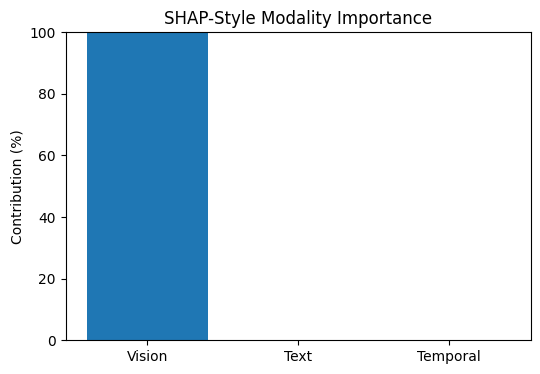

PORTION 10 COMPLETE ✅


In [19]:
# =========================================================
# PORTION 10 : SHAP-STYLE MODALITY IMPORTANCE
# =========================================================

def modality_importance(sample):

    stage1_model.eval()
    stage2_model.eval()

    # -----------------------------------------------------
    # ORIGINAL INPUT
    # -----------------------------------------------------

    frames = sample["frames"].unsqueeze(0).to(
        DEVICE
    )

    text = sample["text"]

    toks = tokenizer(

        [text],

        padding=True,

        truncation=True,

        max_length=128,

        return_tensors="pt"
    )

    input_ids = toks["input_ids"].to(
        DEVICE
    )

    attention_mask = toks[
        "attention_mask"
    ].to(DEVICE)

    # =====================================================
    # ORIGINAL PREDICTION
    # =====================================================

    with torch.no_grad():

        logits1, _ = stage1_model(

            frames,

            input_ids,

            attention_mask
        )

        probs1 = torch.softmax(
            logits1,
            dim=1
        )

        pred1 = torch.argmax(
            probs1,
            dim=1
        ).item()

        # -------------------------------------------------
        # SAFE
        # -------------------------------------------------

        if pred1 == 0:

            original_conf = probs1[
                0,
                0
            ].item()

            pred_label = "safe"

        # -------------------------------------------------
        # STAGE-2
        # -------------------------------------------------

        else:

            logits2, _ = stage2_model(

                frames,

                input_ids,

                attention_mask
            )

            probs2 = torch.softmax(
                logits2,
                dim=1
            )

            pred2 = torch.argmax(
                probs2,
                dim=1
            ).item()

            original_conf = probs2[
                0,
                pred2
            ].item()

            pred_label = stage2_labels[
                pred2
            ]

    # =====================================================
    # REMOVE VISION
    # =====================================================

    zero_frames = torch.zeros_like(
        frames
    )

    with torch.no_grad():

        logits1_v, _ = stage1_model(

            zero_frames,

            input_ids,

            attention_mask
        )

        probs1_v = torch.softmax(
            logits1_v,
            dim=1
        )

        if pred1 == 0:

            vision_removed_conf = probs1_v[
                0,
                0
            ].item()

        else:

            logits2_v, _ = stage2_model(

                zero_frames,

                input_ids,

                attention_mask
            )

            probs2_v = torch.softmax(
                logits2_v,
                dim=1
            )

            vision_removed_conf = probs2_v[
                0,
                pred2
            ].item()

    # =====================================================
    # REMOVE TEXT
    # =====================================================

    no_text = tokenizer(

        ["[NO_TEXT]"],

        padding=True,

        truncation=True,

        max_length=128,

        return_tensors="pt"
    )

    no_input_ids = no_text[
        "input_ids"
    ].to(DEVICE)

    no_attention = no_text[
        "attention_mask"
    ].to(DEVICE)

    with torch.no_grad():

        logits1_t, _ = stage1_model(

            frames,

            no_input_ids,

            no_attention
        )

        probs1_t = torch.softmax(
            logits1_t,
            dim=1
        )

        if pred1 == 0:

            text_removed_conf = probs1_t[
                0,
                0
            ].item()

        else:

            logits2_t, _ = stage2_model(

                frames,

                no_input_ids,

                no_attention
            )

            probs2_t = torch.softmax(
                logits2_t,
                dim=1
            )

            text_removed_conf = probs2_t[
                0,
                pred2
            ].item()

    # =====================================================
    # TEMPORAL SHUFFLE
    # =====================================================

    shuffled = frames.clone()

    perm = torch.randperm(16)

    shuffled = shuffled[:,perm]

    with torch.no_grad():

        logits1_s, _ = stage1_model(

            shuffled,

            input_ids,

            attention_mask
        )

        probs1_s = torch.softmax(
            logits1_s,
            dim=1
        )

        if pred1 == 0:

            temporal_removed_conf = probs1_s[
                0,
                0
            ].item()

        else:

            logits2_s, _ = stage2_model(

                shuffled,

                input_ids,

                attention_mask
            )

            probs2_s = torch.softmax(
                logits2_s,
                dim=1
            )

            temporal_removed_conf = probs2_s[
                0,
                pred2
            ].item()

    # =====================================================
    # IMPORTANCE SCORES
    # =====================================================

    vision_imp = max(

        original_conf -
        vision_removed_conf,

        0
    )

    text_imp = max(

        original_conf -
        text_removed_conf,

        0
    )

    temporal_imp = max(

        original_conf -
        temporal_removed_conf,

        0
    )

    total = (

        vision_imp
        +
        text_imp
        +
        temporal_imp
        +
        1e-8
    )

    vision_pct = 100 * vision_imp / total

    text_pct = 100 * text_imp / total

    temporal_pct = 100 * temporal_imp / total

    # =====================================================
    # PRINT
    # =====================================================

    print("\n==============================")
    print("MODALITY IMPORTANCE")
    print("==============================")

    print(f"Prediction : {pred_label}")

    print(f"Confidence : {original_conf:.4f}")

    print()

    print(f"Vision   : {vision_pct:.2f}%")

    print(f"Text     : {text_pct:.2f}%")

    print(f"Temporal : {temporal_pct:.2f}%")

    # =====================================================
    # BARPLOT
    # =====================================================

    labels = [

        "Vision",

        "Text",

        "Temporal"
    ]

    values = [

        vision_pct,

        text_pct,

        temporal_pct
    ]

    plt.figure(figsize=(6,4))

    plt.bar(
        labels,
        values
    )

    plt.ylabel(
        "Contribution (%)"
    )

    plt.title(
        "SHAP-Style Modality Importance"
    )

    plt.ylim(0,100)

    plt.show()

# =========================================================
# RUN
# =========================================================

modality_importance(sample)

print("PORTION 10 COMPLETE ✅")



# =========================================================
# FIND VIDEO IDS BY CATEGORY
# =========================================================

def get_video_by_category(

    category_name,

    limit=1
):

    found = []

    for i in range(len(test_dataset)):

        s = test_dataset[i]

        vid = s["video_id"]

        label1 = s["label_stage1"].item()

        label2 = s["label_stage2"].item()

        # -------------------------------------------------
        # SAFE
        # -------------------------------------------------

        if category_name == "safe":

            if label1 == 0:

                found.append(vid)

        # -------------------------------------------------
        # STAGE2
        # -------------------------------------------------

        else:

            if label2 != -1:

                if stage2_labels[label2] == category_name:

                    found.append(vid)

        if len(found) >= limit:

            break

    return found


RUNNING DEMO FOR: TEST_PM_046

VIDEO INFORMATION
Video ID:
TEST_PM_046

Dataset Split:
test

TRUE STAGE1:
misleading

TRUE STAGE2:
perception_manipulation

MODEL PREDICTION
Predicted Label : perception_manipulation
Confidence      : 0.8295

FRAME IMPORTANCE
Frame 01 | score=0.0044
Frame 02 | score=0.0051
Frame 03 | score=0.0491
Frame 04 | score=0.0950 <-- TOP
Frame 05 | score=0.0612
Frame 06 | score=0.0465
Frame 07 | score=0.0300
Frame 08 | score=0.0565
Frame 09 | score=0.0571
Frame 10 | score=0.0991 <-- TOP
Frame 11 | score=0.1146 <-- TOP
Frame 12 | score=0.0719
Frame 13 | score=0.0624
Frame 14 | score=0.0821
Frame 15 | score=0.0843
Frame 16 | score=0.0807


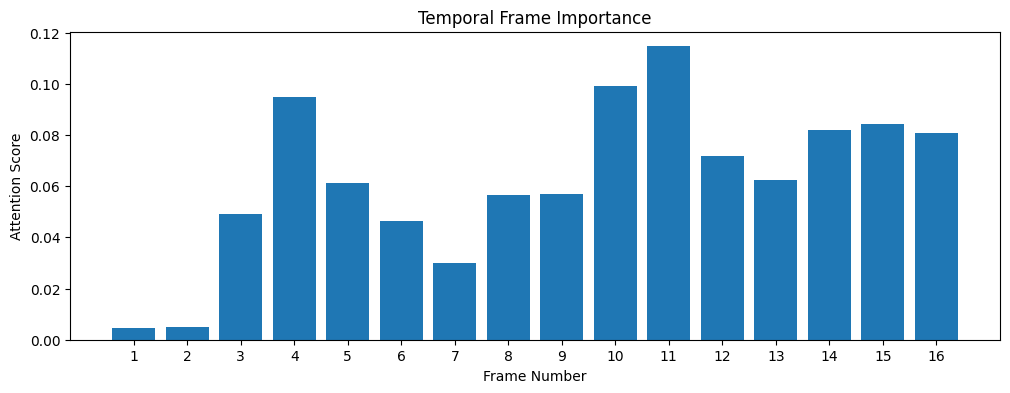


Top Frames:
[11 10  4]


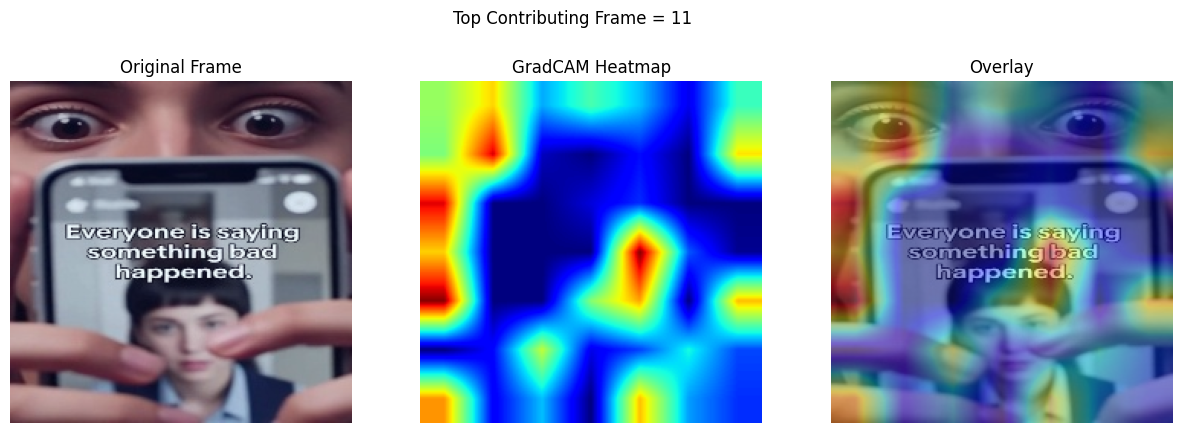


MODALITY IMPORTANCE
Prediction : perception_manipulation
Confidence : 0.8295

Vision   : 98.32%
Text     : 1.68%
Temporal : 0.00%


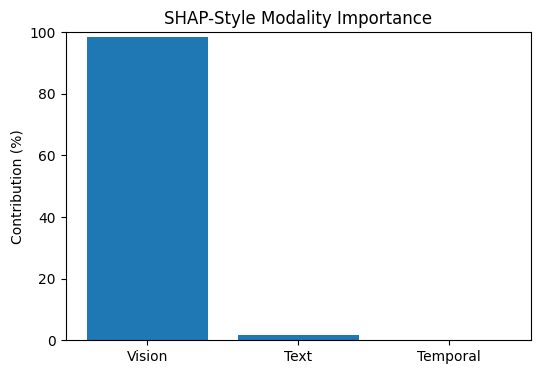


RUNNING DEMO FOR: TEST_IF_023

VIDEO INFORMATION
Video ID:
TEST_IF_023

Dataset Split:
test

TRUE STAGE1:
misleading

TRUE STAGE2:
identity_fabrication

MODEL PREDICTION
Predicted Label : identity_fabrication
Confidence      : 0.981

FRAME IMPORTANCE
Frame 01 | score=0.0316
Frame 02 | score=0.0648
Frame 03 | score=0.0615
Frame 04 | score=0.0638
Frame 05 | score=0.0636
Frame 06 | score=0.0669 <-- TOP
Frame 07 | score=0.0614
Frame 08 | score=0.0636
Frame 09 | score=0.0645
Frame 10 | score=0.0624
Frame 11 | score=0.0716 <-- TOP
Frame 12 | score=0.0665
Frame 13 | score=0.0677 <-- TOP
Frame 14 | score=0.0650
Frame 15 | score=0.0599
Frame 16 | score=0.0653


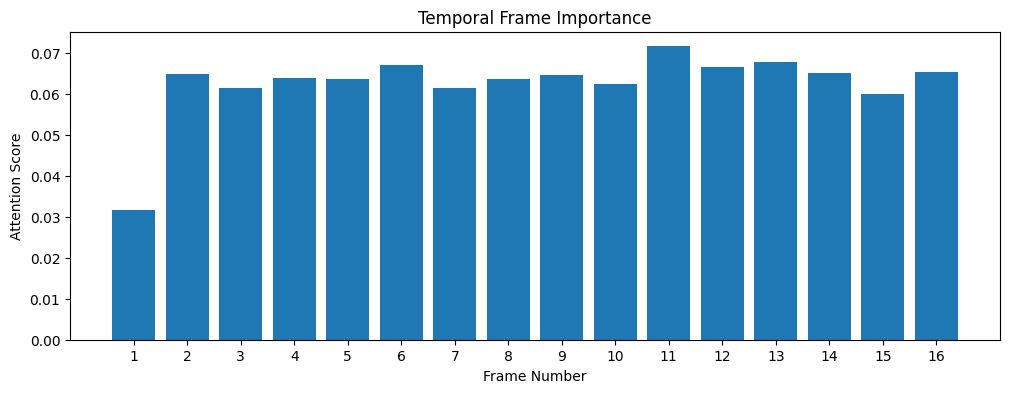


Top Frames:
[11 13  6]


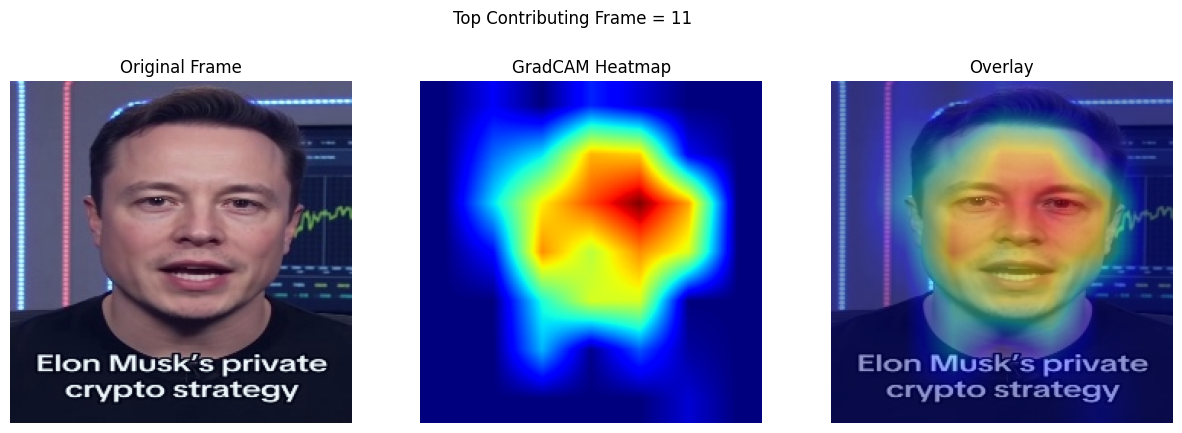


MODALITY IMPORTANCE
Prediction : identity_fabrication
Confidence : 0.9810

Vision   : 99.84%
Text     : 0.16%
Temporal : 0.00%


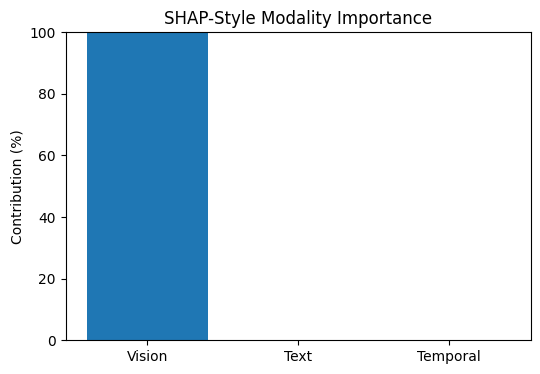


RUNNING DEMO FOR: TEST_SC_023

VIDEO INFORMATION
Video ID:
TEST_SC_023

Dataset Split:
test

TRUE STAGE1:
misleading

TRUE STAGE2:
surreal_content

MODEL PREDICTION
Predicted Label : surreal_content
Confidence      : 0.8908

FRAME IMPORTANCE
Frame 01 | score=0.2153 <-- TOP
Frame 02 | score=0.0418
Frame 03 | score=0.0385
Frame 04 | score=0.0357
Frame 05 | score=0.0488
Frame 06 | score=0.0566
Frame 07 | score=0.0466
Frame 08 | score=0.0737 <-- TOP
Frame 09 | score=0.0671
Frame 10 | score=0.0433
Frame 11 | score=0.0475
Frame 12 | score=0.0723
Frame 13 | score=0.0822 <-- TOP
Frame 14 | score=0.0486
Frame 15 | score=0.0430
Frame 16 | score=0.0391


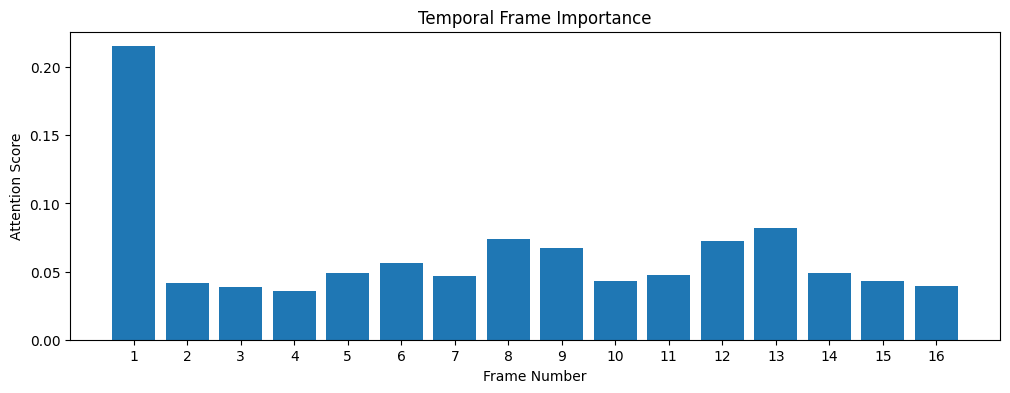


Top Frames:
[ 1 13  8]


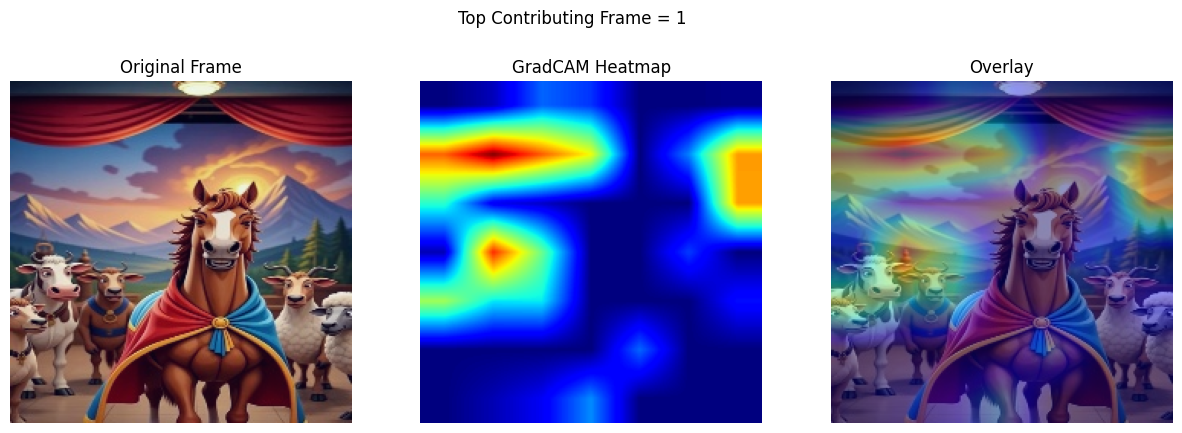


MODALITY IMPORTANCE
Prediction : surreal_content
Confidence : 0.8908

Vision   : 98.50%
Text     : 1.50%
Temporal : 0.00%


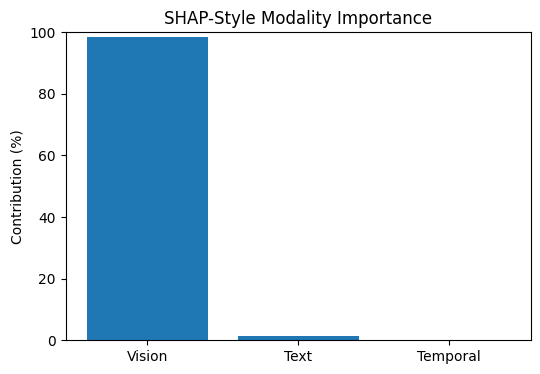


RUNNING DEMO FOR: TEST_SUS_039

VIDEO INFORMATION
Video ID:
TEST_SUS_039

Dataset Split:
test

TRUE STAGE1:
misleading

TRUE STAGE2:
scientifically_unrealistic_scene

MODEL PREDICTION
Predicted Label : scientifically_unrealistic_scene
Confidence      : 0.8487

FRAME IMPORTANCE
Frame 01 | score=0.0169
Frame 02 | score=0.0182
Frame 03 | score=0.0272
Frame 04 | score=0.0186
Frame 05 | score=0.0182
Frame 06 | score=0.0655
Frame 07 | score=0.0903
Frame 08 | score=0.0853
Frame 09 | score=0.0985 <-- TOP
Frame 10 | score=0.0818
Frame 11 | score=0.0703
Frame 12 | score=0.1553 <-- TOP
Frame 13 | score=0.1147 <-- TOP
Frame 14 | score=0.0942
Frame 15 | score=0.0278
Frame 16 | score=0.0171


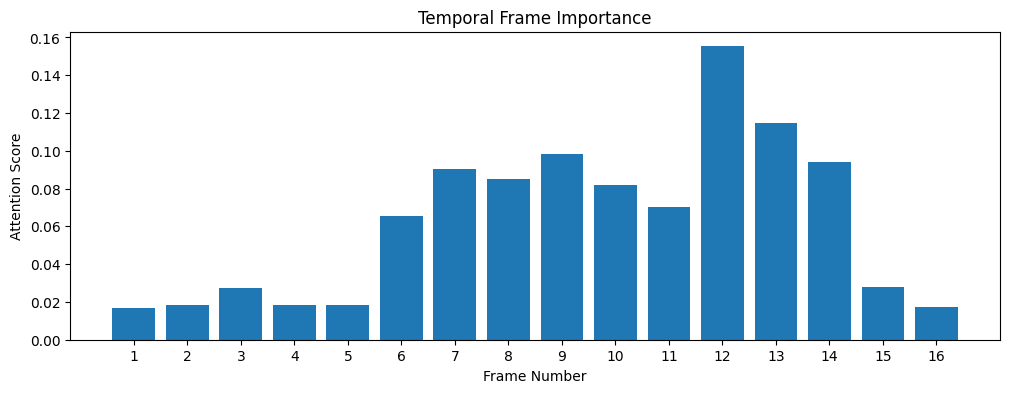


Top Frames:
[12 13  9]


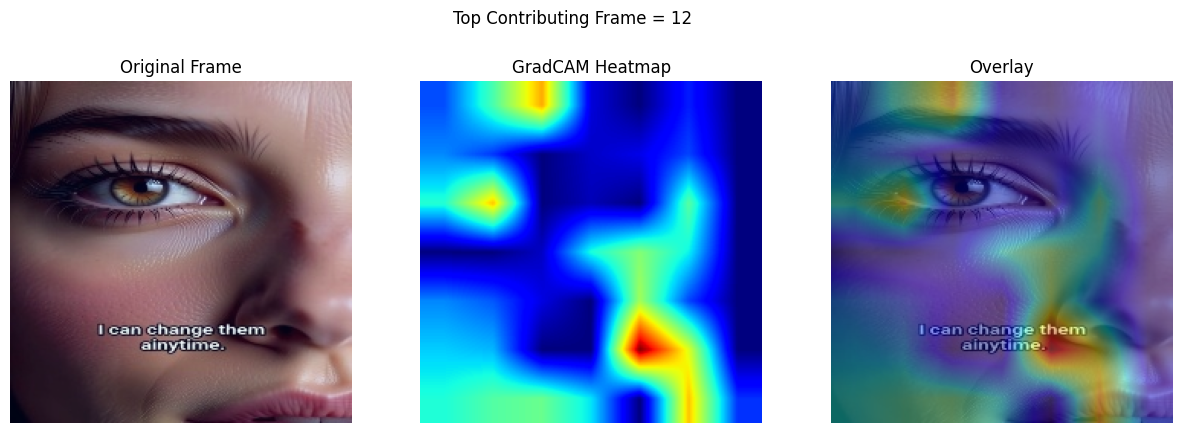


MODALITY IMPORTANCE
Prediction : scientifically_unrealistic_scene
Confidence : 0.8487

Vision   : 100.00%
Text     : 0.00%
Temporal : 0.00%


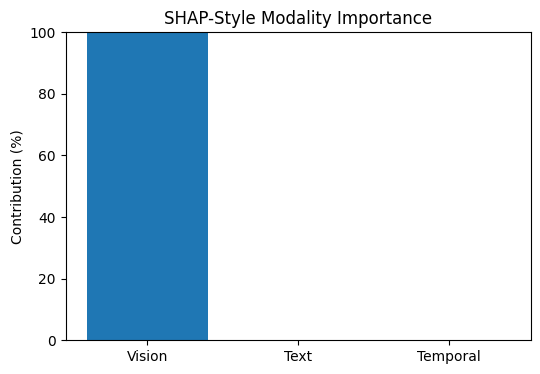


RUNNING DEMO FOR: TEST_SAFE_055

VIDEO INFORMATION
Video ID:
TEST_SAFE_055

Dataset Split:
test

TRUE STAGE1:
safe

MODEL PREDICTION
Predicted Label : safe
Confidence      : 0.7681

FRAME IMPORTANCE
Frame 01 | score=0.0613
Frame 02 | score=0.0637
Frame 03 | score=0.0659
Frame 04 | score=0.0721 <-- TOP
Frame 05 | score=0.0930 <-- TOP
Frame 06 | score=0.0650
Frame 07 | score=0.0573
Frame 08 | score=0.0429
Frame 09 | score=0.0669
Frame 10 | score=0.0601
Frame 11 | score=0.0537
Frame 12 | score=0.0617
Frame 13 | score=0.0747 <-- TOP
Frame 14 | score=0.0623
Frame 15 | score=0.0432
Frame 16 | score=0.0560


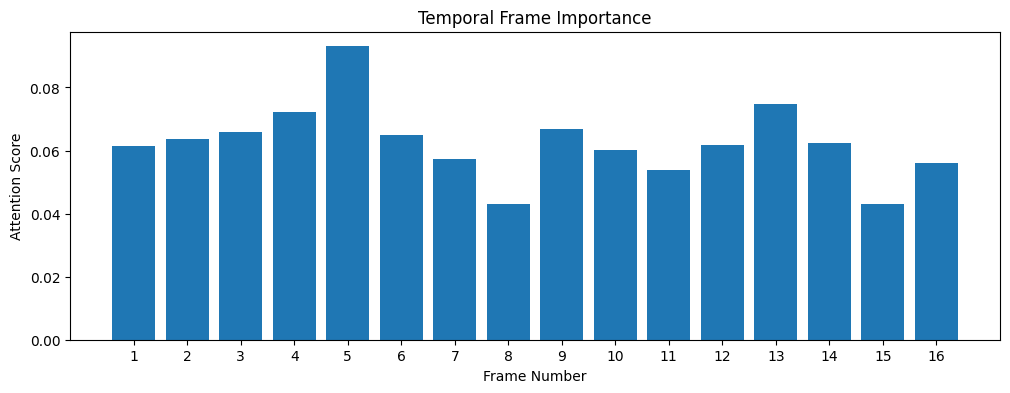


Top Frames:
[ 5 13  4]


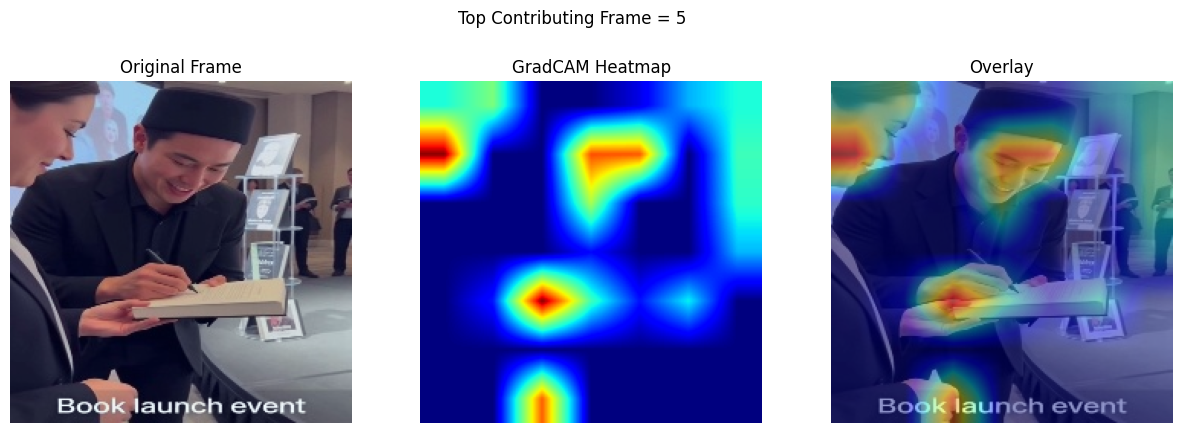


MODALITY IMPORTANCE
Prediction : safe
Confidence : 0.7681

Vision   : 93.58%
Text     : 6.42%
Temporal : 0.00%


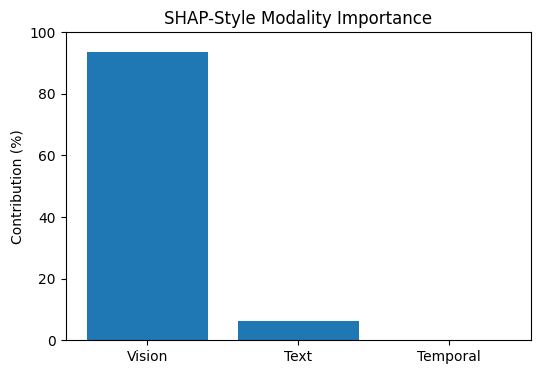

In [20]:
# =========================================================
# FINAL THESIS DEMONSTRATION
# =========================================================

demo_videos = [

    "TEST_PM_046",

    "TEST_IF_023",

    "TEST_SC_023",

    "TEST_SUS_039",

    "TEST_SAFE_055"
]

for vid in demo_videos:

    print("\n" + "="*80)

    print(f"RUNNING DEMO FOR: {vid}")

    print("="*80)

    # -----------------------------------------------------
    # PREDICTION
    # -----------------------------------------------------

    predict_by_video_id(vid)

    # -----------------------------------------------------
    # SHAP STYLE
    # -----------------------------------------------------

    # get sample again

    sample = None

    for i in range(len(test_dataset)):

        s = test_dataset[i]

        if s["video_id"] == vid:

            sample = s
            break

    modality_importance(sample)